In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

import pyNeuroDAP as ndap

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Each neuron: laser_mod_index <--> left_right_tone_index, left_right_lick_index, reward_index

- tone: 25 ms
- reward is delivered as soon as the first selection lick is detected
- ENL: 1500 + np.ranodom(0,500)

## 1. Load the data from folder

In [2]:
# import tkinter as tk
# from tkinter import filedialog
# # Hide the main tkinter window
# root = tk.Tk()
# root.withdraw()

# # Open a dialog to select the session folder
# base_folder = filedialog.askdirectory(title="Select session folder", initialdir=r"/Users/shunli/Downloads/sabalab/forPaolo")
# # Extract the session_id from the selected folder name
# session_id = os.path.basename(base_folder)
# print(f"Selected session_id: {session_id}")
# print(f"Base folder: {base_folder}")

In [3]:
# Hard loading

# base_folder = rf"/Users/shunli/Projects/pyNeuroDAP/Data/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001"

# base_folder = rf"/Volumes/MICROSCOPE/Paolo/FromFor/ForShun_InVivo/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001"
# base_folder = rf"/Volumes/MICROSCOPE/Paolo/FromFor/ForShun_InVivo/Rec_Upstream_DCN_1_250323_5mW_500ms_500delay_032325001"
# base_folder = rf"/Volumes/MICROSCOPE/Paolo/FromFor/ForShun_InVivo/Rec_Upstream_DCN_1_250328_Licking_032825001"
base_folder = rf"/Volumes/Neurobio/MICROSCOPE/Paolo/FromFor/ForShun_Invivo2/Rec_Upstream_DCN_3_260807ok_5mWBlue_500ms_080726001"

# Extract the session_id from the last part of the path
session_id = os.path.basename(base_folder)
print(f"Selected session_id: {session_id}")

Selected session_id: Rec_Upstream_DCN_3_260807ok_5mWBlue_500ms_080726001


In [4]:
# Which results folder to load: 'newest', or an explicit name e.g. 'results-260913-good'
results_folder_mode = 'newest'

import re

def resolve_results_folder(base_folder, mode='newest'):
    """
    Pick a results folder inside base_folder.

    mode='newest' takes the most recent results-YYMMDD[-tag] folder, ranked by
    the date in the folder name and then by modification time (so same-day runs
    with different unit selections resolve to the one written last). Any other
    value is treated as an explicit folder name.

    Only folders holding both data.h5 and aligned_spikes.h5 are considered, so
    an interrupted run is never picked.
    """
    required = ('data.h5', 'aligned_spikes.h5')

    if mode != 'newest':
        folder = os.path.join(base_folder, mode)
        if not os.path.isdir(folder):
            raise FileNotFoundError(f"Results folder not found: {folder}")
        return folder

    candidates = [
        d for d in os.listdir(base_folder)
        if d.startswith('results-')
        and all(os.path.isfile(os.path.join(base_folder, d, f)) for f in required)
    ]
    if not candidates:
        available = sorted(d for d in os.listdir(base_folder) if d.startswith('results-'))
        raise FileNotFoundError(
            f"No complete results folder (needs {' + '.join(required)}) in {base_folder}.\n"
            f"results-* folders present: {available or 'none'}"
        )

    def sort_key(name):
        match = re.match(r'results-(\d{6})', name)
        date = match.group(1) if match else ''
        return (date, os.path.getmtime(os.path.join(base_folder, name)))

    return os.path.join(base_folder, max(candidates, key=sort_key))

results_folder = resolve_results_folder(base_folder, results_folder_mode)
print(f"Results folder: {os.path.basename(results_folder)}")

# Load data from hdf5 file
# Define data structures
data, trial_table, event_times, metadata = {}, {}, {}, {}
aligned_trial_start, aligned_choice_lick, aligned_second_lick, aligned_last_lick = {}, {}, {}, {}
_open_h5 = {}

data_path = os.path.join(results_folder, "data.h5")
data = ndap.load_session_data(data_path)

trial_table = ndap.load_dataframe(data_path, key='trial_table')
event_times = data['event_times']
metadata = data['metadata']

# Load aligned spikes
spikes_path = os.path.join(results_folder, "aligned_spikes.h5")
aligned_spikes = ndap.load_aligned_spikes(spikes_path)

aligned_trial_start = aligned_spikes['trial_start']
aligned_choice_lick = aligned_spikes['choice_lick']
aligned_second_lick = aligned_spikes['second_lick']
aligned_last_lick = aligned_spikes['last_lick']

time_range = tuple(map(float, metadata['time_range'].strip('()').split(',')))
bin_size = metadata['bin_size']
xaxis = ndap.get_time_axis(time_range, bin_size_ms=bin_size)
print(f"Time range: {time_range}, Bin size: {bin_size}")
print(f"Units: {metadata.get('unit_selection', 'unknown')} "
      f"(laser session: {metadata.get('has_laser', 'unknown')})")


Results folder: results-260915-good_excellent_mua
Analysis data loaded for session: /Volumes/Neurobio/MICROSCOPE/Paolo/FromFor/ForShun_Invivo2/Rec_Upstream_DCN_3_260807ok_5mWBlue_500ms_080726001/results-260915-good_excellent_mua/data.h5
Aligned spikes loaded from /Volumes/Neurobio/MICROSCOPE/Paolo/FromFor/ForShun_Invivo2/Rec_Upstream_DCN_3_260807ok_5mWBlue_500ms_080726001/results-260915-good_excellent_mua/aligned_spikes.h5 (lazy=True)
Time range: (-1.0, 5.0), Bin size: 25
Units: good_excellent_mua (laser session: True)


## 2. Get modulation index

- Tone
- Choice lick (left vs right encoding)
- reward
- laser

In [5]:
mod_index_type = 'norm'

# ####################### Window definitions ########################
# Timing the session records is read from the data (laser onset/duration, bin
# size, artifact bin). Only the response-window *lengths* below are analysis
# choices, and they all live in one place.

# Laser timing comes from the session's own behavior files (see
# ndap.get_laser_timing for the source priority and its rationale)
laser_timing = ndap.get_laser_timing(session_folder=base_folder, trial_table=trial_table)
laser_source = laser_timing['onset_source'] or 'not detected'

if laser_timing['has_laser']:
    laser_onset = laser_timing['laser_onset']
    laser_duration = laser_timing['laser_duration']
    print(f"Laser: {laser_timing['n_laser_trials']} trials, onset {laser_onset:.4f}s, "
          f"duration {laser_duration:.3f}s")
    print(f"  onset from {laser_timing['onset_source']}, "
          f"duration from {laser_timing['duration_source']}")
else:
    # control session: keep placeholders so the windows below stay defined
    laser_onset, laser_duration = 0.0, 0.5
    print("Laser: no laser trials in this session")
for warning in laser_timing['warnings']:
    print(f"  ! {warning}")

# Laser on/offset produce an electrical artifact that lands in the onset bin,
# so every laser window starts one full bin after the event.
artifact_skip_ms = float(bin_size)

# --- windows derived from the session ---
laser_window    = (artifact_skip_ms, laser_duration * 1000)   # the pulse itself
baseline_window = (-500, 0)                                   # pre-trial, within time_range

# --- windows that are analysis choices (response durations) ---
tone_window   = (0, 50)
choice_window = (0, 75)
motor_window  = (0, 100)
reward_window = (0, 200)
motor_ref_window = (150, 250)     # late reference for the motor index
tone_ref_window  = (-75, -25)     # pre-tone reference

# Behavioural timing in this session, for judging whether the lengths above fit
for col, label in [('FirstLickLatency', 'first-lick latency'), ('LickDuration', 'lick bout duration'),
                   ('TimeDelta', 'trial duration')]:
    if col in trial_table.columns:
        v = trial_table[col].dropna()
        if len(v):
            print(f"  median {label}: {v.median():.3f}s")
print(f"  windows (ms): tone {tone_window}, choice {choice_window}, motor {motor_window}, "
      f"reward {reward_window}, laser {tuple(round(w) for w in laser_window)}")


# ----------------------------- Tone -----------------------------
tone_rates = ndap.combine_rates(aligned_trial_start, key=['control'])
ctrl_rates = ndap.combine_rates(aligned_trial_start, key=['control'])
tone_rates = ndap.get_window(tone_rates, onset_time=0, window_ms=tone_window, bin_size_ms=bin_size, xaxis=xaxis)
ctrl_rates = ndap.get_window(ctrl_rates, onset_time=0, window_ms=tone_ref_window, bin_size_ms=bin_size, xaxis=xaxis)
tone_mod_index = ndap.get_mod_index(tone_rates, ctrl_rates, type=mod_index_type)


# ----------------------------- Choice (left vs right encoding) -----------------------------
left_rates = ndap.combine_rates(aligned_choice_lick, key=['left','control'])
right_rates = ndap.combine_rates(aligned_choice_lick, key=['right','control'])
left_rates = ndap.get_window(left_rates, onset_time=0, window_ms=choice_window, bin_size_ms=bin_size, xaxis=xaxis)
right_rates = ndap.get_window(right_rates, onset_time=0, window_ms=choice_window, bin_size_ms=bin_size, xaxis=xaxis)
choice_mod_index = ndap.get_mod_index(left_rates, right_rates, type=mod_index_type)


# ----------------------------- Motor -----------------------------
lick_rates = ndap.combine_rates(aligned_last_lick, key=['control'])
ctrl_rates = ndap.combine_rates(aligned_last_lick, key=['control'])
lick_rates = ndap.get_window(lick_rates, onset_time=0, window_ms=motor_window, bin_size_ms=bin_size, xaxis=xaxis)
ctrl_rates = ndap.get_window(ctrl_rates, onset_time=0, window_ms=motor_ref_window, bin_size_ms=bin_size, xaxis=xaxis)
motor_mod_index = ndap.get_mod_index(lick_rates, ctrl_rates, type=mod_index_type)


# ----------------------------- Reward -----------------------------
reward_rates = ndap.combine_rates(aligned_second_lick, key=['reward','control'])
nonreward_rates = ndap.combine_rates(aligned_second_lick, key=['nonreward','control'])
reward_rates = ndap.get_window(reward_rates, onset_time=0, window_ms=reward_window, bin_size_ms=bin_size, xaxis=xaxis)
nonreward_rates = ndap.get_window(nonreward_rates, onset_time=0, window_ms=reward_window, bin_size_ms=bin_size, xaxis=xaxis)
reward_mod_index = ndap.get_mod_index(reward_rates, nonreward_rates, type=mod_index_type)


# ----------------------------- Laser -----------------------------
# laser vs control in the same window (NOT response vs own baseline)
laser_rates = ndap.combine_rates(aligned_trial_start, key=['laser'])
control_rates = ndap.combine_rates(aligned_trial_start, key=['control'])
laser_rates = ndap.get_window(laser_rates, onset_time=laser_onset, window_ms=laser_window, bin_size_ms=bin_size, xaxis=xaxis)
control_rates = ndap.get_window(control_rates, onset_time=laser_onset, window_ms=laser_window, bin_size_ms=bin_size, xaxis=xaxis)
laser_mod_index = ndap.get_mod_index(laser_rates, control_rates, type=mod_index_type)


# ----------------------------- Robust laser statistics -----------------------------
# The ratio index above contrasts laser vs control in one window. On its own it
# cannot separate a real laser drive from a unit that is merely *less suppressed*
# than control, and it compresses large absolute effects (a +14 Hz change on an
# active unit can score lower than +1 Hz on a near-silent one). So also report:
#   interaction  - (laser change from baseline) - (control change from baseline), in Hz
#   AUROC        - per-trial separability, 0.5 = no difference, no denominator to blow up
#   p            - Mann-Whitney on per-trial rates
#   task index   - control response vs its own baseline, for context
from scipy.stats import mannwhitneyu

laser_trials_rate = ndap.convert_dask_to_numpy(ndap.combine_rates(aligned_trial_start, key=['laser']))
control_trials_rate = ndap.convert_dask_to_numpy(ndap.combine_rates(aligned_trial_start, key=['control']))

resp_mask = (xaxis >= laser_onset + artifact_skip_ms / 1000) & (xaxis <= laser_onset + laser_duration)
base_mask = (xaxis >= baseline_window[0] / 1000) & (xaxis < baseline_window[1] / 1000)

L_resp = np.nanmean(laser_trials_rate[:, :, resp_mask], axis=2)      # (units, trials)
L_base = np.nanmean(laser_trials_rate[:, :, base_mask], axis=2)
C_resp = np.nanmean(control_trials_rate[:, :, resp_mask], axis=2)
C_base = np.nanmean(control_trials_rate[:, :, base_mask], axis=2)


def auroc(a, b):
    """P(a random trial from a exceeds one from b); 0.5 means no difference"""
    a, b = np.asarray(a)[np.isfinite(a)], np.asarray(b)[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    return mannwhitneyu(a, b, alternative='two-sided').statistic / (len(a) * len(b))


n_units = L_resp.shape[0]
laser_interaction_hz = np.full(n_units, np.nan)
laser_auroc = np.full(n_units, np.nan)
laser_pvalue = np.full(n_units, np.nan)
task_index = np.full(n_units, np.nan)

for u in range(n_units):
    laser_interaction_hz[u] = ((np.nanmean(L_resp[u]) - np.nanmean(L_base[u]))
                               - (np.nanmean(C_resp[u]) - np.nanmean(C_base[u])))
    laser_auroc[u] = auroc(L_resp[u], C_resp[u])
    if np.isfinite(laser_auroc[u]):
        laser_pvalue[u] = mannwhitneyu(L_resp[u], C_resp[u], alternative='two-sided').pvalue
    task_index[u] = ((np.nanmean(C_resp[u]) - np.nanmean(C_base[u]))
                     / (np.nanmean(C_resp[u]) + np.nanmean(C_base[u]) + 1e-12))


def describe(u):
    """Put the laser effect in the context of what the task alone does"""
    if not np.isfinite(laser_pvalue[u]) or laser_pvalue[u] >= 0.05:
        return 'not significant'
    direction = 'increase' if laser_interaction_hz[u] > 0 else 'decrease'
    if task_index[u] < -0.2:
        return f'task-suppressed, laser {"relieves" if laser_interaction_hz[u] > 0 else "deepens"} it'
    if task_index[u] > 0.2:
        return f'task-excited, laser {direction}s it'
    return f'laser-driven {direction}'


print(f"\nLaser effect, window {laser_onset + artifact_skip_ms/1000:.3f}-"
      f"{laser_onset + laser_duration:.3f} s, ranked by |interaction|:")
print(f"{'unit':>4s} {'ratio':>7s} {'interact':>9s} {'AUROC':>6s} {'p':>8s} {'task':>6s}  interpretation")
for u in np.argsort(-np.abs(laser_interaction_hz))[:10]:
    print(f"{u:4d} {laser_mod_index[u]:+7.3f} {laser_interaction_hz[u]:+8.2f}Hz {laser_auroc[u]:6.3f} "
          f"{laser_pvalue[u]:8.4f} {task_index[u]:+6.2f}  {describe(u)}")
print(f"  {int(np.nansum(laser_pvalue < 0.05))}/{n_units} units reach p<0.05 "
      f"(ranking the rest is noise)")


# --- laser effect with licking held constant (needs trial_indices in event_times) ---
# Laser trials lick later and less, and the laser window overlaps the first lick,
# so a laser-vs-control difference can just be a lick difference. Compare only
# trials with no lick inside the window.
if 'trial_indices' in event_times and 'FirstLickLatency' in trial_table.columns:
    lick_free_cut = laser_onset + laser_duration      # no lick before the window ends

    def gather(unit, want_laser):
        rates, bases, lats = [], [], []
        for cond, idx in event_times['trial_indices'].items():
            if ('laser' in cond) != want_laser:
                continue
            idx = np.asarray(idx, dtype=int)
            if not len(idx):
                continue
            rate = np.asarray(aligned_trial_start[cond]['rate'])[unit]
            rates.append(np.nanmean(rate[:, resp_mask], axis=1))
            bases.append(np.nanmean(rate[:, base_mask], axis=1))
            lats.append(trial_table.iloc[idx]['FirstLickLatency'].values)
        return (np.concatenate(rates), np.concatenate(bases), np.concatenate(lats))

    def is_lick_free(lat):
        return (~np.isfinite(lat)) | (lat >= lick_free_cut)

    print(f"\nSame units with licking held constant (no lick before {lick_free_cut:.2f} s):")
    print(f"{'unit':>4s} {'all: idx':>9s} {'p':>8s} {'lick-free: idx':>15s} {'AUROC':>6s} {'p':>8s} {'n L/C':>9s}")
    for u in np.argsort(-np.abs(laser_interaction_hz))[:10]:
        lr, lb, llat = gather(u, True)
        cr, cb, clat = gather(u, False)
        mL, mC = is_lick_free(llat), is_lick_free(clat)
        if mL.sum() < 5 or mC.sum() < 5:
            print(f"{u:4d} {laser_mod_index[u]:+9.3f} {laser_pvalue[u]:8.4f} {'too few trials':>15s}")
            continue
        L, C = lr[mL], cr[mC]
        idx_lf = (L.mean() - C.mean()) / (L.mean() + C.mean() + 1e-12)
        p_lf = mannwhitneyu(L, C, alternative='two-sided').pvalue
        print(f"{u:4d} {laser_mod_index[u]:+9.3f} {laser_pvalue[u]:8.4f} {idx_lf:+15.3f} "
              f"{auroc(L, C):6.3f} {p_lf:8.4f} {int(mL.sum()):4d}/{int(mC.sum()):<4d}")
    print("  an effect that survives here is not explained by the lick difference")
else:
    print("\n(no trial_indices in this results folder - re-run the script to enable "
          "the lick-controlled comparison)")


# ----------------------------- Convert to numpy array -----------------------------
tone_mod_index = ndap.convert_dask_to_numpy(tone_mod_index)
choice_mod_index = ndap.convert_dask_to_numpy(choice_mod_index)
motor_mod_index = ndap.convert_dask_to_numpy(motor_mod_index)
reward_mod_index = ndap.convert_dask_to_numpy(reward_mod_index)
laser_mod_index = ndap.convert_dask_to_numpy(laser_mod_index)


# ----------------------------- Print top 5 excited and suppressed neurons -----------------------------
idx_excited = np.argsort(tone_mod_index)[-5:][::-1]
idx_supp    = np.argsort(tone_mod_index)[:5]
print("Top 5 excited neurons by tone:", idx_excited, tone_mod_index[idx_excited])
print("Top 5 suppressed neurons by tone:", idx_supp, tone_mod_index[idx_supp])

idx_excited = np.argsort(choice_mod_index)[-5:][::-1]
idx_supp    = np.argsort(choice_mod_index)[:5]
print("Top 5 excited neurons by choice:", idx_excited, choice_mod_index[idx_excited])
print("Top 5 suppressed neurons by choice", idx_supp, choice_mod_index[idx_supp])

idx_excited = np.argsort(motor_mod_index)[-5:][::-1]
idx_supp    = np.argsort(motor_mod_index)[:5]
print("Top 5 excited neurons by motor:", idx_excited, motor_mod_index[idx_excited])
print("Top 5 suppressed neurons by motor:", idx_supp, motor_mod_index[idx_supp])

idx_excited = np.argsort(reward_mod_index)[-5:][::-1]
idx_supp    = np.argsort(reward_mod_index)[:5]
print("Top 5 excited neurons by reward:", idx_excited, reward_mod_index[idx_excited])
print("Top 5 suppressed neurons by reward:", idx_supp, reward_mod_index[idx_supp])

idx_excited = np.argsort(laser_mod_index)[-5:][::-1]
idx_supp    = np.argsort(laser_mod_index)[:5]
print("Top 5 excited neurons by laser:", idx_excited, laser_mod_index[idx_excited])
print("Top 5 suppressed neurons by laser:", idx_supp, laser_mod_index[idx_supp])


Laser: 114 trials, onset 0.0019s, duration 0.500s
  onset from measured (DetectedLaserDelay_s), duration from configured (LaserWidth_s)
  ! configured delay 0.500s disagrees with measured 0.002s
  median first-lick latency: 0.213s
  median lick bout duration: 1.231s
  median trial duration: 4.386s
  windows (ms): tone (0, 50), choice (0, 75), motor (0, 100), reward (0, 200), laser (25, 500)
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 're

### 2.3 Poisson GLM: every event's weight from one fit

The window indices in the previous section each contrast two groups of trials over a
fixed window. That is confounded here: the laser fires at tone onset **and** changes
behaviour (laser trials lick later and less often, and the laser window overlaps the
first lick), so a unit that is merely less lick-suppressed on laser trials scores as
"excited by laser".

This section fits **one Poisson regression per unit** over all trials and bins, with a
separate kernel for each event. Every kernel is estimated simultaneously, so each one
carries only the variance the others cannot explain — and the laser weight becomes
directly comparable with the tone, motor, choice and reward weights, because all five
come from the same fit in the same units (Hz).

$$\log \lambda(t) = \beta_0 + \sum_{e} k_e * s_e(t)$$

Each kernel $k_e$ is a weighted sum of raised-cosine bumps convolved with that event's
impulse train $s_e(t)$:

| kernel | aligned to | sign | span | bumps |
|---|---|---|---|---|
| tone | trial start, every trial | on / off | 1.2 s | 8 |
| laser | laser onset, laser trials | on / off | 1.0 s | 6 |
| lick_left | every **left** lick | on / off | 0.5 s | 5 |
| lick_right | every **right** lick | on / off | 0.5 s | 5 |
| reward | first lick | **+1 rewarded, −1 not** | 1.0 s | 5 |

Licks are split by side rather than pooled into one motor kernel and a signed
first-lick choice kernel. That version fit worse on 22 of 27 units (mean ΔAIC −155 at
identical parameter count), used only the 354 first licks instead of all 3174, and was
keyed to the *cued* `TrialSide` — which disagrees with the side actually licked on every
incorrect trial. Splitting also lets the two sides have different response shapes.

**Motor and choice are derived** from the pair, so the five familiar weights still exist:

- `motor` = what the two sides share, (k_left + k_right)/2; its p-value tests whether
  either lick kernel is non-zero.
- `choice` = how they differ, k_left − k_right; its p-value is a Wald test of
  **k_left = k_right**, i.e. genuine side selectivity.

**Readouts.** `glm_effects[name]` is a counterfactual rate change in Hz. For the
unsigned kernels (tone, laser, lick_left, lick_right) it is the predicted rate with that
kernel active minus the prediction with it switched off — for the lick kernels, averaged
over the bins where that kernel actually contributes. For the **signed** reward kernel
switching off is meaningless, so it is the contrast between the two levels (the same
trials predicted as rewarded vs not). `glm_kernels[name]` holds the fitted time course as
a multiplicative gain.

**Inference.** `statsmodels` fits the Poisson GLM and supplies a covariance **clustered
by trial**, which is essential: bins within a trial are correlated, and treating each
bin as independent inflates significance by orders of magnitude. `glm_pvalues[name]` is
a Wald test on that kernel's whole block of coefficients.

**Three caveats.**
1. *Mediation.* If the laser genuinely changes licking, the motor kernel absorbs part of
   the laser's real downstream effect. This is the **direct** effect; the window index is
   the **total** effect. Report both.
2. The Wald test asks whether a kernel is non-zero *anywhere in its time course*, while
   the Hz number is its *net average* effect. A biphasic kernel can therefore be highly
   significant with a near-zero net effect — read the two together, and the kernel shape
   when they disagree.
3. Cluster-robust standard errors reduce but do not fully remove the anti-conservatism
   from within-trial correlation. Treat small p-values as approximate.

In [ ]:
# ---- config ----
glm_fit_window   = (-0.5, 2.0)    # s from trial start; keep it tight for speed
glm_min_spikes   = 100            # response viability: spikes in the fit window
glm_min_rate_hz  = 0.5            # response viability: mean rate
glm_cv_folds     = 5              # held-out D^2, split by trial
glm_sig_level    = 0.05
n_circular_shifts   = 50          # 0 disables the shift null, which dominates runtime
shift_test_kernels  = ['laser']   # which kernels get a shift null
# Runtime scales as n_units x n_circular_shifts x len(shift_test_kernels); the defaults
# above take roughly 3 minutes for ~25 units. Set n_circular_shifts = 0 while iterating.

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.signal import fftconvolve

if 'trial_indices' not in event_times:
    raise RuntimeError("event_times has no 'trial_indices' - re-run "
                       "analyze_sessions_forPlexon.py to regenerate this session")

dt = float(bin_size) / 1000
checks = []      # (stage, check, status, detail)


def record(stage, check, status, detail):
    checks.append((stage, check, status, detail))


# ---- counts plus the matching trial rows (this is what trial_indices enables) ----
count_blocks, row_blocks = [], []
for cond, idx in event_times['trial_indices'].items():
    idx = np.asarray(idx, dtype=int)
    if not len(idx):
        continue
    count_blocks.append(np.asarray(aligned_trial_start[cond]['count']))
    row_blocks.append(idx)
counts = np.concatenate(count_blocks, axis=1)
glm_trials = trial_table.iloc[np.concatenate(row_blocks)]

fit_mask = (xaxis >= glm_fit_window[0]) & (xaxis <= glm_fit_window[1])
x_fit = xaxis[fit_mask]
counts = counts[:, :, fit_mask]
n_units, n_trials, n_bins = counts.shape

# Pooling semantics: sorted units are session-scoped, so exactly one session per fit.
# There is no correct way to pool them in a single call.
record('pooling', 'response scope', 'PASS',
       f'session_scoped, 1 session, {n_trials} trials - never pooled across sessions')


def raised_cosine_basis(n_basis, span):
    """n_basis raised-cosine bumps tiling [0, span] seconds"""
    centers = np.linspace(0, span, n_basis)
    width = (centers[1] - centers[0]) * 2 if n_basis > 1 else span
    lags = np.arange(0, span + width + dt, dt)
    basis = np.zeros((n_basis, len(lags)))
    for k, c in enumerate(centers):
        d = (lags - c) * np.pi / width
        inside = np.abs(d) < np.pi
        basis[k, inside] = 0.5 * (1 + np.cos(d[inside]))
    return basis, lags


def event_impulses(times_per_trial, weights=None):
    """Event times relative to trial start -> (trials, bins), optionally signed"""
    out = np.zeros((n_trials, n_bins))
    weights = np.ones(n_trials) if weights is None else np.asarray(weights, dtype=float)
    for t, (times, w) in enumerate(zip(times_per_trial, weights)):
        if not np.isfinite(w):
            continue
        for v in np.atleast_1d(times):
            if np.isfinite(v):
                b = int(np.searchsorted(x_fit, v)) - 1
                if 0 <= b < n_bins:
                    out[t, b] += w
    return out


def convolve_basis(impulses, basis):
    """Convolved per trial, truncated at the trial edge, so no kernel crosses a boundary"""
    return np.stack([fftconvolve(impulses, basis[k][None, :], mode='full', axes=1)[:, :n_bins]
                     for k in range(basis.shape[0])])


# ---- the events ----
starts = glm_trials['TimeStart'].values
first_lick = glm_trials['FirstLickLatency'].values
is_laser_trial = glm_trials['IsLaserTrial'].values == 1
reward_sign = np.where(glm_trials['RMI'].values == 'reward', 1.0, -1.0)

# Licks are split by the side actually licked (lick_sides: 1 = right, 0 = left).
# This keys on what the animal did, not on the cued TrialSide - the two differ on
# every incorrect trial - and it uses all licks rather than only the first.
left_licks, right_licks = [], []
for lt, ls, s in zip(glm_trials['lick_times'].values, glm_trials['lick_sides'].values, starts):
    if isinstance(lt, (list, np.ndarray)) and len(lt):
        rel, sides = np.asarray(lt, dtype=float) - s, np.asarray(ls)
        left_licks.append(rel[sides == 0])
        right_licks.append(rel[sides == 1])
    else:
        left_licks.append(np.nan)
        right_licks.append(np.nan)

kernel_specs = {}
for name, impulses, (basis, lags), rows, is_signed in [
    ('tone',       event_impulses([0.0] * n_trials),        raised_cosine_basis(8, 1.2),
     (np.ones(n_trials, bool), (x_fit >= 0) & (x_fit <= 0.5)), False),
    ('laser',      event_impulses([laser_onset if l else np.nan for l in is_laser_trial]),
                                                            raised_cosine_basis(6, 1.0),
     (is_laser_trial, (x_fit >= laser_onset) & (x_fit <= laser_onset + laser_duration)), False),
    ('lick_left',  event_impulses(left_licks),              raised_cosine_basis(5, 0.5),
     'where_active', False),
    ('lick_right', event_impulses(right_licks),             raised_cosine_basis(5, 0.5),
     'where_active', False),
    ('reward',     event_impulses(first_lick, reward_sign), raised_cosine_basis(5, 1.0),
     (np.isfinite(first_lick), np.ones(n_bins, bool)), True),
]:
    kernel_specs[name] = dict(impulses=impulses, basis=basis, lags=lags,
                              rows=rows, signed=is_signed)

columns, names = [], []
for name, spec in kernel_specs.items():
    block = convolve_basis(spec['impulses'], spec['basis'])
    for k in range(block.shape[0]):
        columns.append(block[k].reshape(-1))
        names.append(f'{name}_{k}')
X = sm.add_constant(np.column_stack(columns), has_constant='add')   # intercept first
names = np.array(names)
trial_id = np.repeat(np.arange(n_trials), n_bins)
block_of = {n: np.r_[False, np.char.startswith(names, n + '_')] for n in kernel_specs}

# ####################### validation gates: census and design #######################
for name, spec in kernel_specs.items():
    n_ev = int(np.sum(spec['impulses'] != 0))
    L = spec['basis'].shape[0]
    status = 'FAIL' if n_ev < L else ('WARN' if n_ev < 10 * L else 'PASS')
    record('census', f'events per free parameter [{name}]', status, f'N={n_ev}, L={L}, N/L={n_ev/L:.0f}')

const_cols = int((X[:, 1:].var(axis=0) == 0).sum())
record('census', 'predictor variance', 'FAIL' if const_cols else 'PASS',
       f'{const_cols} constant column(s)')
n_nan = int(np.isnan(X).sum() + np.isnan(counts).sum())
record('census', 'missing values', 'FAIL' if n_nan else 'PASS', f'{n_nan} NaN in design/response')

total_spikes = counts.sum(axis=(1, 2))
mean_rate = total_spikes / (n_trials * n_bins * dt)
viable = (total_spikes >= glm_min_spikes) & (mean_rate >= glm_min_rate_hz)
record('census', 'response viability', 'PASS' if viable.any() else 'FAIL',
       f'{int(viable.sum())}/{n_units} units pass (>={glm_min_spikes} spikes and '
       f'>={glm_min_rate_hz} Hz); {int((~viable).sum())} excluded')

# between-group collinearity: within-kernel lag correlation is collinear by construction,
# so each kernel is regressed on the OTHER kernels only
group_sum = {g: X[:, block_of[g]].sum(axis=1) for g in kernel_specs}
pairs = [(a, b, np.corrcoef(group_sum[a], group_sum[b])[0, 1])
         for i, a in enumerate(kernel_specs) for b in list(kernel_specs)[i + 1:]]
max_r = max(abs(r) for *_, r in pairs)
record('design', 'group correlation', 'FAIL' if max_r > 0.95 else ('WARN' if max_r > 0.8 else 'PASS'),
       f'max |r| = {max_r:.3f} ({max(pairs, key=lambda p: abs(p[2]))[0]} x '
       f'{max(pairs, key=lambda p: abs(p[2]))[1]})')

worst_vif, worst_group = 0.0, None
for g in kernel_specs:
    Xg, Xo = X[:, block_of[g]], np.column_stack([np.ones(len(X)), X[:, ~block_of[g]][:, 1:]])
    for j in range(Xg.shape[1]):
        beta, *_ = np.linalg.lstsq(Xo, Xg[:, j], rcond=None)
        ss_res = np.sum((Xg[:, j] - Xo @ beta) ** 2)
        ss_tot = np.sum((Xg[:, j] - Xg[:, j].mean()) ** 2)
        if ss_tot > 0:
            v = 1 / max(1 - (1 - ss_res / ss_tot), 1e-12)
            if v > worst_vif:
                worst_vif, worst_group = v, g
record('design', 'between-group VIF', 'WARN' if worst_vif > 10 else 'PASS',
       f'max {worst_vif:.1f} ({worst_group}); within-kernel lag correlation excluded')

sv = np.linalg.svd(X, compute_uv=False)
rank = int((sv > sv.max() * max(X.shape) * np.finfo(float).eps).sum())
cond = sv.max() / sv.min()
record('design', 'rank and conditioning',
       'FAIL' if (rank < X.shape[1] or cond > 1e10) else 'PASS',
       f'rank {rank}/{X.shape[1]}, condition number {cond:.3g}')

# temporal locking: a partner event at a near-constant offset cannot be separated
event_times_by_trial = {}
for g, spec in kernel_specs.items():
    tr, b = np.nonzero(spec['impulses'])
    event_times_by_trial[g] = (tr, x_fit[b])
locked = []
for a in kernel_specs:
    for b in kernel_specs:
        if a == b:
            continue
        ta, xa = event_times_by_trial[a]
        tb, xb = event_times_by_trial[b]
        offsets = []
        for tr in np.unique(ta):
            bb = xb[tb == tr]
            if not len(bb):
                continue
            for v in xa[ta == tr]:
                offsets.append(bb[np.argmin(np.abs(bb - v))] - v)
        if len(offsets) < 10:
            continue
        offsets = np.asarray(offsets)
        iqr_bins = (np.percentile(offsets, 75) - np.percentile(offsets, 25)) / dt
        coverage = len(offsets) / max(len(xa), 1)
        if iqr_bins < 2 and coverage > 0.8:
            locked.append(f'{a}->{b} at {np.median(offsets)*1000:+.0f} ms '
                          f'(IQR {iqr_bins:.2f} bins, {100*coverage:.0f}% of events)')
record('design', 'temporal locking', 'WARN' if locked else 'PASS',
       '; '.join(locked) if locked else 'no near-constant partner offsets')
record('design', 'lag window vs trial boundary', 'PASS',
       'convolution is per trial and truncated at the edge')
record('design', 'response in own predictors', 'PASS', 'task-only model, no coupling terms')


# ####################### fit #######################
def poisson_deviance(y, mu):
    mu = np.clip(mu, 1e-10, None)
    with np.errstate(divide='ignore', invalid='ignore'):
        term = np.where(y > 0, y * np.log(y / mu), 0.0)
    return 2 * np.sum(term - (y - mu))


def d2(y, mu, mu_null):
    """Deviance explained relative to an intercept-only model"""
    null = poisson_deviance(y, mu_null)
    return 1 - poisson_deviance(y, mu) / null if null > 0 else np.nan


derived = ['motor', 'choice']
glm_effects = {n: np.full(n_units, np.nan) for n in list(kernel_specs) + derived}
glm_pvalues = {n: np.full(n_units, np.nan) for n in list(kernel_specs) + derived}
glm_delta_d2 = {n: np.full(n_units, np.nan) for n in kernel_specs}
glm_kernels = {n: np.full((n_units, len(s['lags'])), np.nan) for n, s in kernel_specs.items()}
for n in derived:
    glm_kernels[n] = np.full((n_units, len(kernel_specs['lick_left']['lags'])), np.nan)
glm_d2_insample = np.full(n_units, np.nan)
glm_d2_heldout = np.full(n_units, np.nan)
glm_d2_shift_p = {n: np.full(n_units, np.nan) for n in shift_test_kernels}
glm_baseline_gain = np.full(n_units, np.nan)
converged, glm_failed = [], []

rng = np.random.default_rng(0)
folds = np.array_split(rng.permutation(n_trials), glm_cv_folds)
tone_only = block_of['tone'].copy()
tone_only[0] = True                       # intercept + position-in-trial
X_by_trial = X.reshape(n_trials, n_bins, -1)

print(f"GLM: {X.shape[0]} observations x {X.shape[1]} regressors "
      f"({n_trials} trials x {n_bins} bins), fitting {int(viable.sum())} viable units")

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for u in range(n_units):
        if not viable[u]:
            continue
        y = counts[u].reshape(-1).astype(float)
        try:
            fit = sm.GLM(y, X, family=sm.families.Poisson()).fit(
                cov_type='cluster', cov_kwds={'groups': trial_id, 'use_correction': True})
            plain = sm.GLM(y, X, family=sm.families.Poisson()).fit()
        except Exception as err:
            glm_failed.append((u, type(err).__name__))
            continue
        converged.append(bool(plain.converged))

        mu_null = np.full_like(y, y.mean())
        glm_d2_insample[u] = d2(y, plain.predict(X), mu_null)

        num = den = 0.0                    # held out by TRIAL, never by bin
        for f in folds:
            test = np.isin(trial_id, f)
            trained = sm.GLM(y[~test], X[~test], family=sm.families.Poisson()).fit()
            num += poisson_deviance(y[test], trained.predict(X[test]))
            den += poisson_deviance(y[test], np.full(int(test.sum()), y[~test].mean()))
        glm_d2_heldout[u] = 1 - num / den if den > 0 else np.nan

        base = sm.GLM(y, X[:, tone_only], family=sm.families.Poisson()).fit()
        glm_baseline_gain[u] = glm_d2_insample[u] - d2(y, base.predict(X[:, tone_only]), mu_null)

        log_kernel = {}
        for name, spec in kernel_specs.items():
            block = block_of[name]
            if isinstance(spec['rows'], str):        # 'where_active'
                rows = (X[:, block] != 0).any(axis=1)
            else:
                active, window = spec['rows']
                rows = (active[:, None] & window[None, :]).reshape(-1)
            X_on = X[rows]
            X_off = X_on.copy()
            if spec['signed']:
                X_off[:, block] *= -1        # same rows at the opposite level
            else:
                X_off[:, block] = 0          # kernel switched off
            glm_effects[name][u] = (fit.predict(X_on).mean() - fit.predict(X_off).mean()) / dt
            glm_pvalues[name][u] = float(fit.wald_test(np.eye(X.shape[1])[block],
                                                       scalar=True).pvalue)
            log_kernel[name] = spec['basis'].T @ fit.params[block]
            glm_kernels[name][u] = np.exp(log_kernel[name])
            reduced = sm.GLM(y, X[:, ~block], family=sm.families.Poisson()).fit()
            glm_delta_d2[name][u] = glm_d2_insample[u] - d2(y, reduced.predict(X[:, ~block]), mu_null)

        # --- derived: motor is what the two sides share, choice is how they differ ---
        glm_effects['motor'][u] = (glm_effects['lick_left'][u] + glm_effects['lick_right'][u]) / 2
        glm_effects['choice'][u] = glm_effects['lick_left'][u] - glm_effects['lick_right'][u]
        glm_kernels['motor'][u] = np.exp((log_kernel['lick_left'] + log_kernel['lick_right']) / 2)
        glm_kernels['choice'][u] = np.exp(log_kernel['lick_left'] - log_kernel['lick_right'])
        left_block, right_block = block_of['lick_left'], block_of['lick_right']
        glm_pvalues['motor'][u] = float(fit.wald_test(
            np.eye(X.shape[1])[left_block | right_block], scalar=True).pvalue)
        contrast = np.zeros((int(left_block.sum()), X.shape[1]))
        contrast[np.arange(int(left_block.sum())), np.where(left_block)[0]] = 1.0
        contrast[np.arange(int(right_block.sum())), np.where(right_block)[0]] = -1.0
        glm_pvalues['choice'][u] = float(fit.wald_test(contrast, scalar=True).pvalue)

        # --- circular-shift null: does the kernel beat its own timing destroyed? ---
        # Shifting only this kernel's columns leaves the reduced design untouched, so the
        # reduced fit is the same every iteration and is computed once.
        for name in shift_test_kernels:
            if n_circular_shifts <= 0:
                continue
            block = block_of[name]
            dev_reduced = poisson_deviance(
                y, sm.GLM(y, X[:, ~block], family=sm.families.Poisson()).fit().predict(X[:, ~block]))
            dev_null = poisson_deviance(y, mu_null)
            null = np.empty(n_circular_shifts)
            for i in range(n_circular_shifts):
                shifted = X_by_trial.copy()
                for t in range(n_trials):       # circular within trial, keeps event count
                    shifted[t][:, block] = np.roll(X_by_trial[t][:, block],
                                                   rng.integers(1, n_bins), axis=0)
                Xs = shifted.reshape(-1, X.shape[1])
                f_full = sm.GLM(y, Xs, family=sm.families.Poisson()).fit()
                null[i] = (dev_reduced - poisson_deviance(y, f_full.predict(Xs))) / dev_null
            glm_d2_shift_p[name][u] = float((null >= glm_delta_d2[name][u]).mean())

glm_laser_effect, glm_laser_p = glm_effects['laser'], glm_pvalues['laser']

# ####################### validation gates: fit and controls #######################
frac_conv = np.mean(converged) if converged else 0.0
record('fit', 'solver convergence',
       'PASS' if frac_conv >= 0.95 else ('WARN' if frac_conv >= 0.8 else 'FAIL'),
       f'{100*frac_conv:.0f}% of {len(converged)} fits converged')
neg = int(np.nansum(glm_d2_heldout < 0))
n_fit = int(np.isfinite(glm_d2_heldout).sum())
record('fit', 'held-out D^2 below zero', 'WARN' if neg > 0.1 * max(n_fit, 1) else 'PASS',
       f'{neg}/{n_fit} units; median in-sample {np.nanmedian(glm_d2_insample):.4f}, '
       f'held-out {np.nanmedian(glm_d2_heldout):.4f}')
beat = int(np.nansum(glm_baseline_gain > 0.01))
record('control', 'beats trial-time-only baseline', 'PASS' if beat == n_fit else 'WARN',
       f'{beat}/{n_fit} units gain dD^2 > 0.01 over position-in-trial alone')
for name in shift_test_kernels:
    if n_circular_shifts <= 0:
        record('control', f'circular-shift null [{name}]', 'SKIPPED', 'n_circular_shifts = 0')
        continue
    p = glm_d2_shift_p[name]
    passed = int(np.nansum(p < 0.05))
    tested = int(np.isfinite(p).sum())
    record('control', f'circular-shift null [{name}]', 'PASS' if passed == tested else 'WARN',
           f'{passed}/{tested} units beat the 95th percentile of their shifted null')

glm_report = pd.DataFrame(checks, columns=['stage', 'check', 'status', 'detail'])
print("\n===== VALIDATION REPORT =====")
for _, r in glm_report.iterrows():
    print(f"  [{r['status']:7s}] {r['stage']:8s} {r['check']:38s} {r['detail']}")
worst = ('FAIL' if (glm_report.status == 'FAIL').any()
         else 'WARN' if (glm_report.status == 'WARN').any() else 'PASS')
print(f"  overall: {worst}   (glm_report holds the table)")

report_cols = list(kernel_specs) + derived
print(f"\nEffect of each kernel, in Hz (motor and choice are derived from the two lick kernels)")
print(f"{'unit':>4s} " + "".join(f"{n:>19s}" for n in report_cols) + f"{'D2 in/out':>16s}")
for u in np.argsort(-np.abs(np.nan_to_num(glm_effects['laser'])))[:10]:
    if not np.isfinite(glm_effects['laser'][u]):
        continue
    print(f"{u:4d} " + "".join(f"{glm_effects[n][u]:+9.2f}Hz p{glm_pvalues[n][u]:6.3f}"
                               for n in report_cols)
          + f"{glm_d2_insample[u]:8.3f}/{glm_d2_heldout[u]:6.3f}")
print()
for name in report_cols:
    e, pv = glm_effects[name], glm_pvalues[name]
    extra = ''
    if name in kernel_specs:
        dd = glm_delta_d2[name]
        weak = int(np.nansum(dd / np.where(glm_d2_insample > 0, glm_d2_insample, np.nan) < 0.02))
        extra = f" | median dD^2 {np.nanmedian(dd):.4f}, {weak} unit(s) weak (dD^2/D^2 < 0.02)"
    print(f"  {name:10s} |effect| median {np.nanmedian(np.abs(e)):5.2f} Hz, "
          f"max {np.nanmax(np.abs(e)):6.2f} Hz | p<{glm_sig_level} in "
          f"{int(np.nansum(pv < glm_sig_level)):2d}/{n_fit}{extra}")
if glm_failed:
    print(f"\n  {len(glm_failed)} unit(s) failed to fit: {glm_failed}")


GLM: 40100 observations x 30 regressors (401 trials x 100 bins), fitting 24 viable units


**The same two figure styles, now scored entirely by the GLM.**

Every point below is a kernel weight from the fit above, so the laser is compared
against the tone, motor, choice and reward weights on equal terms — same model, same
units (Hz), same trials. That is the comparison the window indices could not make,
because each of those was its own two-group contrast over its own window.

Points outlined in black are significant at `glm_sig_level` (Wald test on the kernel's
coefficient block, clustered by trial). The last figure keeps the window-based laser
measures for reference, to show how far the two approaches agree.

In [ ]:
# GLM kernel weights, in the style of the modulation-index figures.
# The scatter panels use ndap.scatter_with_fit, which draws the scatter, the
# least-squares line, its SEM band and the Spearman correlation, and returns the stats.

glm_sig_level = 0.05
glm_effect_th = 2.0      # Hz, for the pos/neg/no colouring

if 'glm_effects' not in dir():
    raise RuntimeError("run the GLM cell above first")

kernel_order = ['laser', 'tone', 'motor', 'choice', 'reward']

# ---------- 1. strip plot: one row per kernel, all in Hz ----------
fig, axes = plt.subplots(len(kernel_order), 1, figsize=(20, 2.0 * len(kernel_order)))
axes = np.atleast_1d(axes).flatten()
jitter = np.random.normal(loc=0, scale=0.1, size=glm_effects['laser'].size)

all_eff = np.concatenate([glm_effects[k] for k in kernel_order])
lim = np.nanmax(np.abs(all_eff)) * 1.05

for ax, name in zip(axes, kernel_order):
    values = np.asarray(glm_effects[name], dtype=float)
    sig = np.asarray(glm_pvalues[name], dtype=float) < glm_sig_level
    pos = values > glm_effect_th
    neg = values < -glm_effect_th
    none_ = ~pos & ~neg & np.isfinite(values)
    for mask, color, label in [(pos, 'green', 'pos mod'), (neg, 'purple', 'neg mod'),
                               (none_, 'gray', 'no mod')]:
        ax.scatter(values[mask], jitter[mask], color=color, alpha=0.7,
                   edgecolors=np.where(sig[mask], 'black', 'none'), linewidths=1.2, label=label)
    ax.axvline(0, color='k', lw=0.8, ls='--', zorder=0)
    ax.set_xlim(-lim, lim)              # shared scale: all kernels are in Hz
    ax.set_yticks([])
    ax.set_xlabel('rate change (Hz)')
    notes = {'choice': ' [left kernel minus right kernel]',
             'reward': ' [signed: rewarded vs not]',
             'motor': ' [mean of the left and right lick kernels]'}
    signed_note = notes.get(name, '')
    ax.set_title(f"GLM {name} weight{signed_note}   (pos {int(pos.sum())}, neg {int(neg.sum())}, "
                 f"no {int(none_.sum())}, {int(np.nansum(sig))} significant)")
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.005, 0.5))
plt.tight_layout()
plt.show()


# ---------- 2. laser weight vs every other kernel weight, all from the same fit ----------
others = [k for k in kernel_order if k != 'laser']
fig, axes = plt.subplots(1, len(others), figsize=(6 * len(others), 5))
for ax, name in zip(np.atleast_1d(axes), others):
    ndap.scatter_with_fit(glm_effects['laser'], glm_effects[name], ax=ax,
                          xlabel="GLM laser weight (Hz)",
                          ylabel=f"GLM {name} weight (Hz)")
plt.tight_layout()
plt.show()

# ---------- 3. how far the GLM agrees with the window-based laser measures ----------
window_measures = [("Laser Modulation Index", laser_mod_index, True, 0.0),
                   ("Laser Interaction (Hz)", laser_interaction_hz, False, 0.0),
                   ("Laser AUROC", laser_auroc, False, 0.5)]
fig, axes = plt.subplots(1, len(window_measures), figsize=(6 * len(window_measures), 5))
for ax, (y_title, y_index, drop_saturated, y_centre) in zip(np.atleast_1d(axes), window_measures):
    y_index = np.asarray(y_index, dtype=float)
    # a ratio index pinned at +-1 means one side of the ratio was ~0, not a real extreme
    keep = (~np.isclose(np.abs(y_index), 1.0, atol=1e-8) if drop_saturated
            else np.ones(len(y_index), bool))
    ndap.scatter_with_fit(glm_effects['laser'][keep], y_index[keep], ax=ax,
                          xlabel="GLM laser weight (Hz)", ylabel=y_title, y_centre=y_centre)
plt.tight_layout()
plt.show()

### 2.4. Plot modulation index

**What each metric below measures.** All windows are set at the top of the
modulation-index cell; the laser window is derived from the session itself.

**Ratio indices** (`get_mod_index(..., type='norm')`) — mean rate over trials and bins
in window **A** vs window **B**:

$$\text{index} = \frac{\bar{A} - \bar{B}}{\bar{A} + \bar{B}} \in [-1, 1]$$

| metric | aligned to | A | B | trials used |
|---|---|---|---|---|
| Tone | trial start | 0–50 ms | −75 to −25 ms | control only |
| Choice | choice lick | 0–75 ms, **left** | 0–75 ms, **right** | control only |
| Motor | last lick | 0–100 ms | 150–250 ms | control only |
| Reward | second lick | 0–200 ms, **rewarded** | 0–200 ms, **non-rewarded** | control only |
| Laser | trial start | laser window, **laser** trials | same window, **control** trials | both |

Note the two different kinds of contrast. Tone and Motor compare a response window
against a reference window *within the same trials*, so positive means "above its own
baseline". Choice, Reward and Laser compare *two conditions in the same window*, so a
positive Laser index means **more than control**, not more than baseline — a unit that
is suppressed by the task but less suppressed on laser trials still scores positive.

Because it is a ratio, it pins at ±1 whenever one side is near zero. That is a sparse
unit, not a strong effect, which is why the scatter cell drops saturated points.

**Laser Interaction (Hz)** — the same laser contrast expressed as a difference of
differences against a −500 to 0 ms baseline:

$$(\bar{A}_{laser} - \bar{B}_{laser}) - (\bar{A}_{control} - \bar{B}_{control})$$

This removes any pre-existing difference between laser and control trials and reports
the effect in Hz, so a +14 Hz change on an active unit no longer scores below a +1 Hz
change on a near-silent one.

**Laser AUROC** — the probability that a randomly chosen laser trial has a higher rate
than a randomly chosen control trial (ties count a half), from per-trial mean rates in
the laser window. 0.5 means the conditions are indistinguishable. Being rank-based it
cannot saturate, but ties pull it toward 0.5 for sparse units.

**Colour coding** is descriptive, not a statistical test — each row uses its own centre
and threshold (`th` for the ratio rows, `interaction_th` in Hz, `auroc_th` around 0.5).
For significance, use the p-values printed by the modulation-index cell or the GLM.

*Caveat on the Reward index:* `RMI` takes three values in these sessions — `reward`,
`mistrial` and `incorrect` — and the trial conditions treat everything that is not
`reward` as non-rewarded, so "non-rewarded" pools error trials with non-responses.

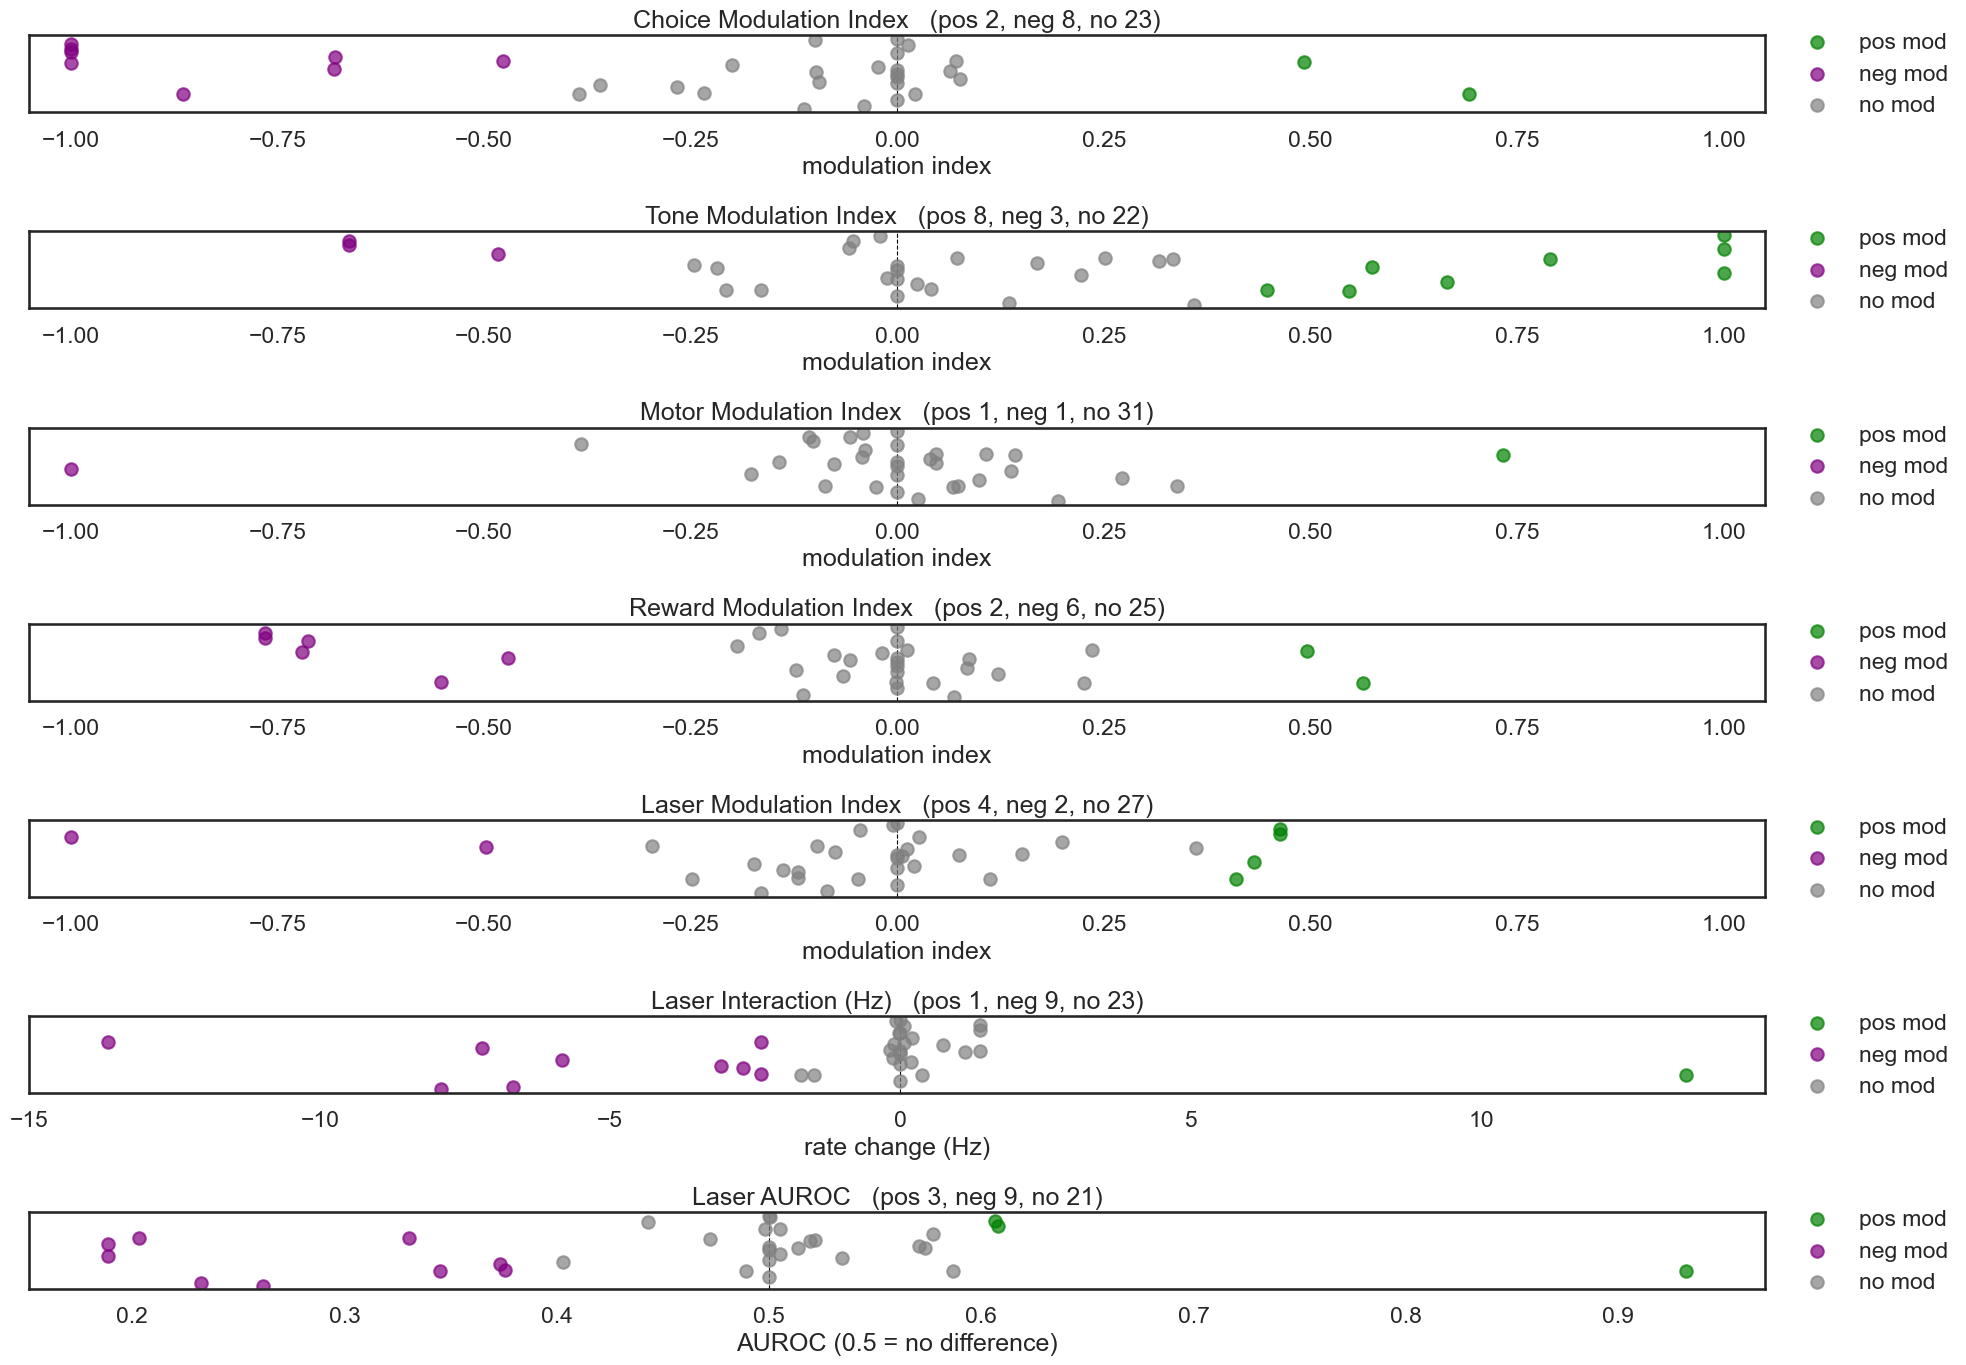

In [ ]:
# Plot and group all modulation indices, one row each
# The ratio indices are bounded [-1, 1] and centred on 0; the laser interaction is in
# Hz (unbounded) and AUROC is centred on 0.5, so each row carries its own centre,
# threshold and x-axis rather than sharing one.
th = 0.4                 # ratio-index threshold
interaction_th = 2.0     # Hz, for the interaction row
auroc_th = 0.1           # distance from 0.5, for the AUROC row

mod_indices = [
    # (title, values, centre, threshold, xlabel)
    ("Choice Modulation Index",  choice_mod_index,      0.0, th,             'modulation index'),
    ("Tone Modulation Index",    tone_mod_index,        0.0, th,             'modulation index'),
    ("Motor Modulation Index",   motor_mod_index,       0.0, th,             'modulation index'),
    ("Reward Modulation Index",  reward_mod_index,      0.0, th,             'modulation index'),
    ("Laser Modulation Index",   laser_mod_index,       0.0, th,             'modulation index'),
    ("Laser Interaction (Hz)",   laser_interaction_hz,  0.0, interaction_th, 'rate change (Hz)'),
    ("Laser AUROC",              laser_auroc,           0.5, auroc_th,       'AUROC (0.5 = no difference)'),
]

fig, axes = plt.subplots(len(mod_indices), 1, figsize=(20, 14))
axes_flat = np.atleast_1d(axes).flatten()

y_jitter = np.random.normal(loc=0, scale=0.1, size=laser_mod_index.size)

pos_mod_color = 'green'
neg_mod_color = 'purple'
no_mod_color = 'gray'

# the bounded ratio rows keep a common x-range so they stay comparable
ratio_values = np.concatenate([v for _, v, c, _, _ in mod_indices if c == 0.0 and np.nanmax(np.abs(v)) <= 1.0])
ratio_xlim = (np.nanmin(ratio_values) - 0.05, np.nanmax(ratio_values) + 0.05)

for ax, (title, mod_index, centre, threshold, xlabel) in zip(axes_flat, mod_indices):
    mod_index = np.asarray(mod_index, dtype=float)
    pos_mask = mod_index > centre + threshold
    neg_mask = mod_index < centre - threshold
    no_mask = ~pos_mask & ~neg_mask & np.isfinite(mod_index)
    ax.scatter(mod_index[pos_mask], y_jitter[pos_mask], color=pos_mod_color, alpha=0.7, label='pos mod')
    ax.scatter(mod_index[neg_mask], y_jitter[neg_mask], color=neg_mod_color, alpha=0.7, label='neg mod')
    ax.scatter(mod_index[no_mask],  y_jitter[no_mask],  color=no_mod_color,  alpha=0.7, label='no mod')
    ax.axvline(centre, color='k', lw=0.8, ls='--', zorder=0)
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_xlabel(xlabel)
    ax.set_title(f"{title}   (pos {int(pos_mask.sum())}, neg {int(neg_mask.sum())}, "
                 f"no {int(no_mask.sum())})")
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.005, 0.5))
    if centre == 0.0 and np.nanmax(np.abs(mod_index)) <= 1.0:
        ax.set_xlim(*ratio_xlim)

plt.tight_layout()


In [ ]:
# Scatter grid: each laser measure (rows) against the other indices (columns),
# with a best-fit line, its SEM band, and the Spearman correlation.
y_indices = [
    ("Choice Modulation Index", choice_mod_index),
    ("Tone Modulation Index", tone_mod_index),
    ("Motor Modulation Index", motor_mod_index),
    ("Reward Modulation Index", reward_mod_index),
]

# rows: the three ways of scoring the laser effect
x_measures = [
    ("Laser Modulation Index", laser_mod_index, True),    # bounded ratio -> drop saturated units
    ("Laser Interaction (Hz)", laser_interaction_hz, False),
    ("Laser AUROC", laser_auroc, False),
]

fig, axes = plt.subplots(len(x_measures), len(y_indices),
                         figsize=(6 * len(y_indices), 5 * len(x_measures)))
axes = np.atleast_2d(axes)
tol = 1e-8

for row, (x_title, x_index, drop_saturated_x) in enumerate(x_measures):
    x_index = np.asarray(x_index, dtype=float)
    for col, (y_title, y_index) in enumerate(y_indices):
        y_index = np.asarray(y_index, dtype=float)

        # A ratio index pinned at +-1 means one side of the ratio was ~0, not a real
        # extreme, so drop those. Interaction and AUROC have no such saturation.
        # Non-finite pairs are dropped by scatter_with_fit itself.
        mask = ~np.isclose(np.abs(y_index), 1.0, atol=tol)
        if drop_saturated_x:
            mask &= ~np.isclose(np.abs(x_index), 1.0, atol=tol)

        ndap.scatter_with_fit(x_index[mask], y_index[mask], ax=axes[row, col],
                              xlabel=x_title, ylabel=y_title, y_centre=0.0,
                              x_centre=0.5 if 'AUROC' in x_title else 0.0)

plt.tight_layout()
plt.show()

Tone modulation index: -0.16504854
Choice modulation index: 0.6913484
Reward modulation index: 0.56410587
Laser modulation index: 0.41015232
Laser interaction: 13.528756141662598
Laser AUROC: 0.9319946206980867


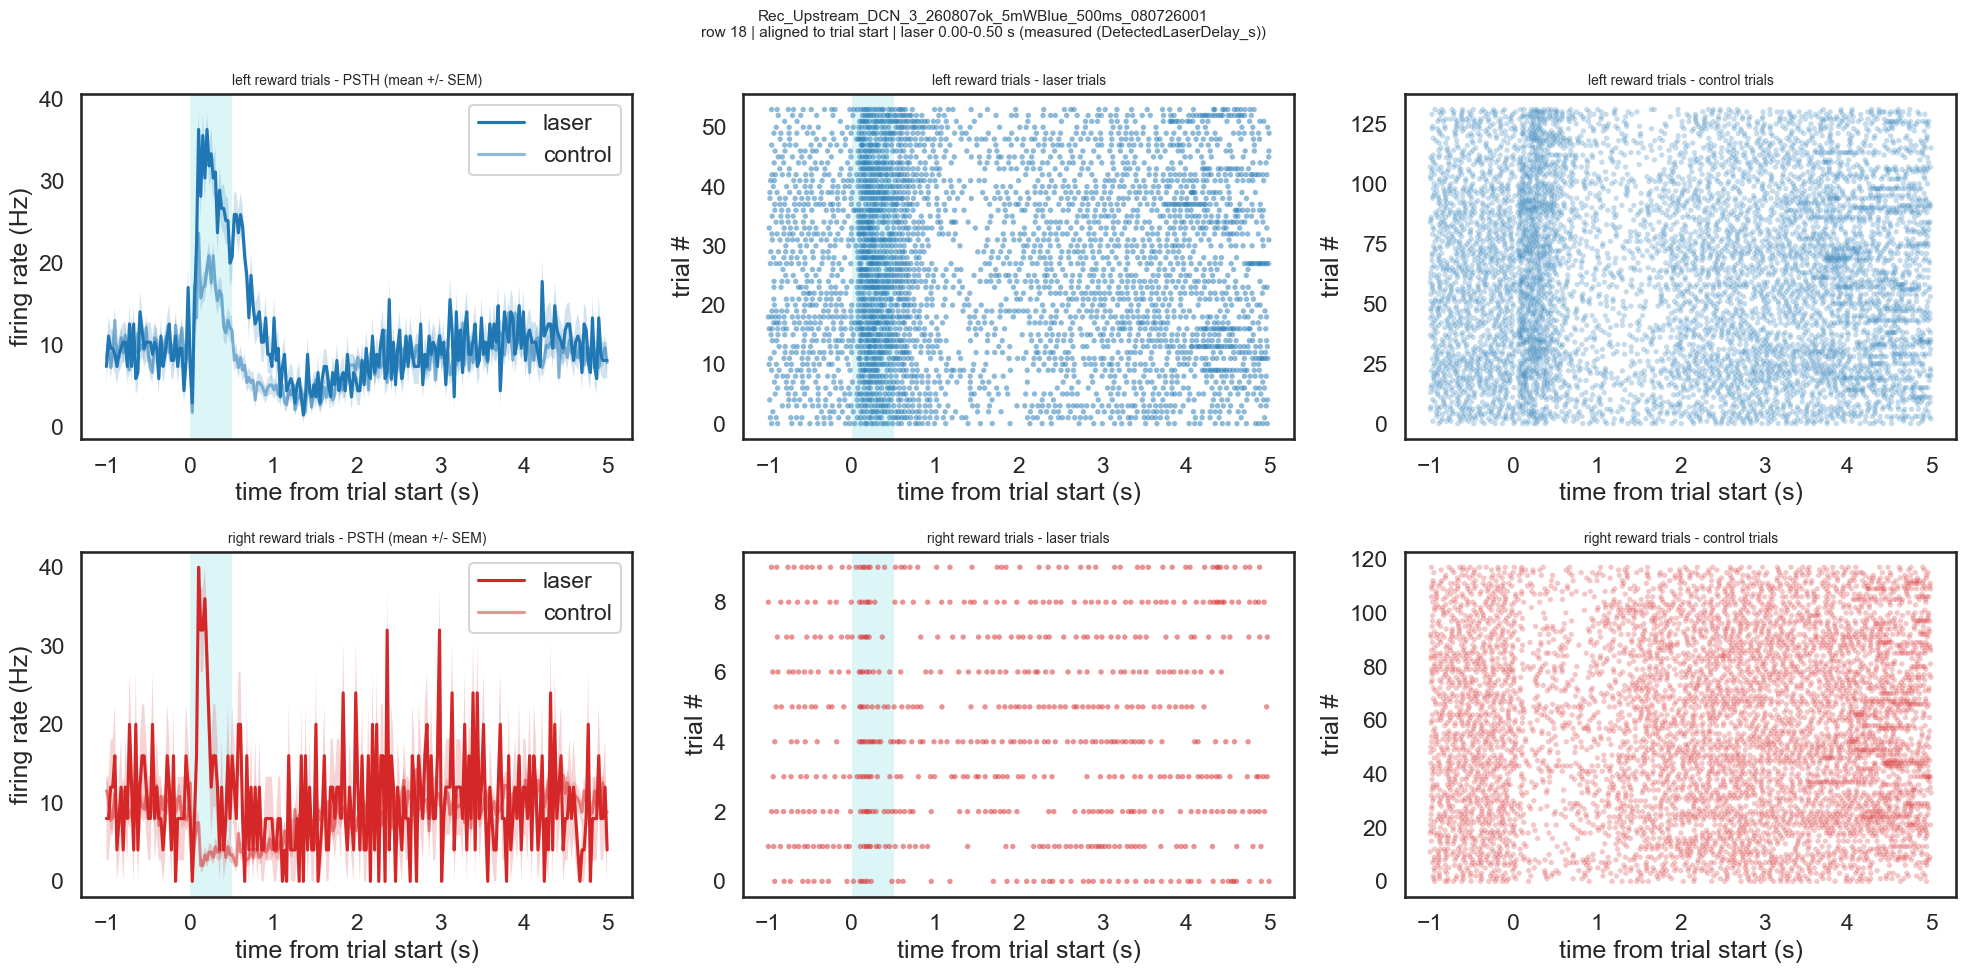

In [ ]:
# Plot firing rate per neuron
# 73: high firing, 23, 67, 37: modulated
fig, ax = plt.subplots(2,3,figsize=(20,10))
unit_id = 18

left_color   = 'tab:blue'
right_color  = 'tab:red'
laser_color  = 'tab:cyan'
alpha_ctrl   = 0.5
alpha_laser  = 1.0

aligned = aligned_trial_start

# Row 0: left trials
ndap.plot_sem(aligned['reward_left_laser']['rate'][unit_id,:,:], x=xaxis, color=left_color, alpha=alpha_laser, plot_individual=False, ax=ax[0,0], label='laser')
ndap.plot_sem(aligned['reward_left_control']['rate'][unit_id,:,:], x=xaxis, color=left_color, alpha=alpha_ctrl, plot_individual=False, ax=ax[0,0], label='control')
ax[0,0].legend()
ndap.plot_raster(aligned['reward_left_laser']['times'][unit_id], x=xaxis, color=left_color, alpha=0.5*alpha_laser, ax=ax[0,1])
ndap.plot_raster(aligned['reward_left_control']['times'][unit_id], x=xaxis, color=left_color, alpha=0.5*alpha_ctrl, ax=ax[0,2])

# Row 1: right trials
ndap.plot_sem(aligned['reward_right_laser']['rate'][unit_id,:,:], x=xaxis, color=right_color, alpha=alpha_laser, plot_individual=False, ax=ax[1,0], label='laser')
ndap.plot_sem(aligned['reward_right_control']['rate'][unit_id,:,:], x=xaxis, color=right_color, alpha=alpha_ctrl, plot_individual=False, ax=ax[1,0], label='control')
ax[1,0].legend()
ndap.plot_raster(aligned['reward_right_laser']['times'][unit_id], x=xaxis, color=right_color, alpha=0.5*alpha_laser, ax=ax[1,1])
ndap.plot_raster(aligned['reward_right_control']['times'][unit_id], x=xaxis, color=right_color, alpha=0.5*alpha_ctrl, ax=ax[1,2])

# ----- label the axes and mark the laser -----
# Everything here is aligned to TRIAL START (event_times['trial_start_times'],
# i.e. the TimeStart column of the trial table). t = 0 is trial start.
col_titles = ['PSTH (mean +/- SEM)', 'laser trials', 'control trials']
row_titles = ['left reward trials', 'right reward trials']
for r in range(2):
    for c in range(3):
        ax[r, c].set_xlabel('time from trial start (s)')
        ax[r, c].set_ylabel('firing rate (Hz)' if c == 0 else 'trial #')
        ax[r, c].set_title(f'{row_titles[r]} - {col_titles[c]}', fontsize=10)
        # laser on only in the PSTH and the laser-trial raster
        if c in (0, 1):
            ax[r, c].axvspan(laser_onset, laser_onset + laser_duration,
                             facecolor=laser_color, alpha=0.15, zorder=0, edgecolor='none',
                             label='laser on' if (r == 0 and c == 1) else None)

unit_label = ''
if 'unit_info' in data:
    ids = [int(u) for u in data['unit_info']['unit_ids']]
    lab = data['unit_info']['unit_labels'][unit_id]
    lab = lab.decode() if isinstance(lab, bytes) else str(lab)
    unit_label = f' | sorter id {ids[unit_id]} ({lab})'
fig.suptitle(f'{session_id}\nrow {unit_id}{unit_label} | aligned to trial start | '
             f'laser {laser_onset:.2f}-{laser_onset + laser_duration:.2f} s ({laser_source})',
             fontsize=11)
fig.tight_layout()


print('Tone modulation index: ' + str(tone_mod_index[unit_id]))
print('Choice modulation index: ' + str(choice_mod_index[unit_id]))
print('Reward modulation index: ' + str(reward_mod_index[unit_id]))
print('Laser modulation index: ' + str(laser_mod_index[unit_id]))
print('Laser interaction: ' + str(laser_interaction_hz[unit_id]))
print('Laser AUROC: ' + str(laser_auroc[unit_id]))

## 3. Plot trajectory aligned to events

In [ ]:
# combine left and right data
criteria = None
aligned = aligned_trial_start

left_rates_control = ndap.combine_rates(aligned, key=['left','control'])
right_rates_control = ndap.combine_rates(aligned, key=['right','control'])
left_rates_laser = ndap.combine_rates(aligned, key=['left','laser'])
right_rates_laser = ndap.combine_rates(aligned, key=['right','laser'])

if criteria is not None:
    left_rates_control = left_rates_control[criteria, :, :]
    right_rates_control = right_rates_control[criteria, :, :]
    left_rates_laser = left_rates_laser[criteria, :, :]
    right_rates_laser = right_rates_laser[criteria, :, :]

left_color   = 'tab:blue'
right_color  = 'tab:red'
alpha_ctrl   = 0.3
alpha_laser  = 1.0

Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']
Combining 2 conditions: ['nonreward_left_laser', 'reward_left_laser']
Combining 2 conditions: ['nonreward_right_laser', 'reward_right_laser']


### 3.1. Plot projection onto CD_choice

/Users/shunli/Projects/pyNeuroDAP/pyNeuroDAP/plots.py:40: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(y, axis=0)
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


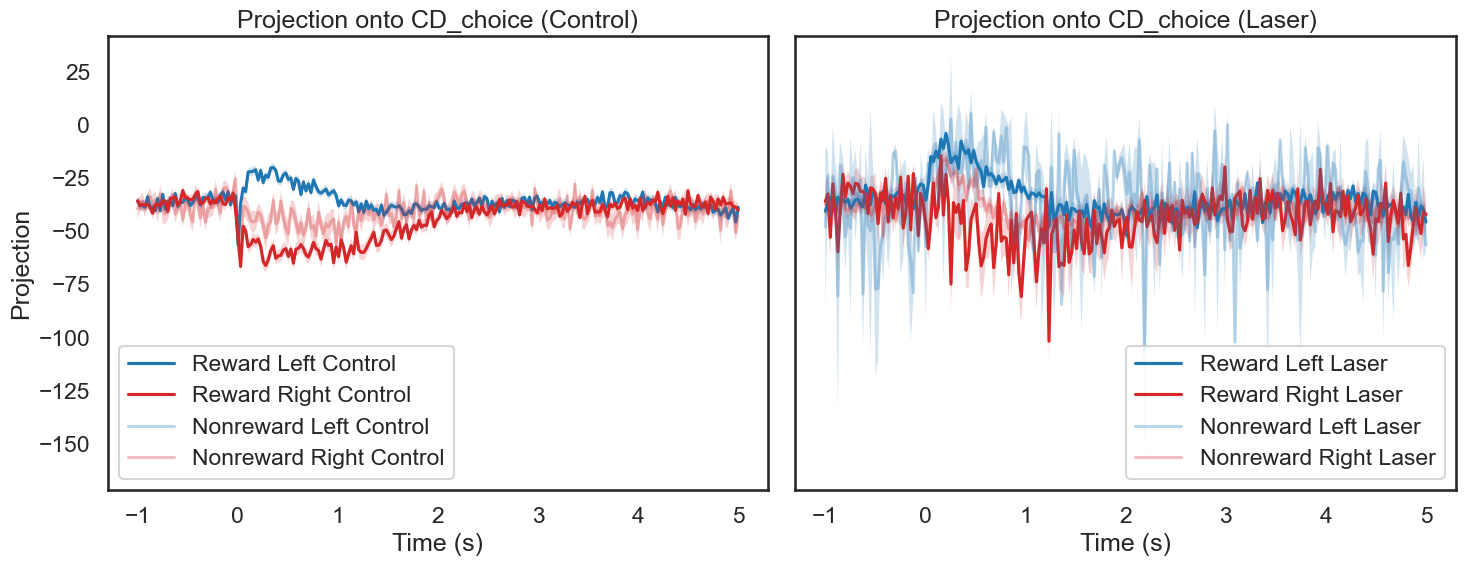

In [ ]:
cd_choice = ndap.get_mod_index(left_rates, right_rates, type='cd')
aligned = aligned_trial_start

# Get projections for control
proj_reward_left_control = ndap.project(aligned['reward_left_control']['rate'], cd=cd_choice)
proj_reward_right_control = ndap.project(aligned['reward_right_control']['rate'], cd=cd_choice)
proj_nonreward_left_control = ndap.project(aligned['nonreward_left_control']['rate'], cd=cd_choice)
proj_nonreward_right_control = ndap.project(aligned['nonreward_right_control']['rate'], cd=cd_choice)

# Get projections for laser
proj_reward_left_laser = ndap.project(aligned['reward_left_laser']['rate'], cd=cd_choice)
proj_reward_right_laser = ndap.project(aligned['reward_right_laser']['rate'], cd=cd_choice)
proj_nonreward_left_laser = ndap.project(aligned['nonreward_left_laser']['rate'], cd=cd_choice)
proj_nonreward_right_laser = ndap.project(aligned['nonreward_right_laser']['rate'], cd=cd_choice)

fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
# Left: Control
ndap.plot_sem(proj_reward_left_control, x=xaxis, color=left_color, alpha=alpha_laser, label='Reward Left Control', ax=axs[0])
ndap.plot_sem(proj_reward_right_control, x=xaxis, color=right_color, alpha=alpha_laser, label='Reward Right Control', ax=axs[0])
ndap.plot_sem(proj_nonreward_left_control, x=xaxis, color=left_color, alpha=alpha_ctrl, label='Nonreward Left Control', ax=axs[0])
ndap.plot_sem(proj_nonreward_right_control, x=xaxis, color=right_color, alpha=alpha_ctrl, label='Nonreward Right Control', ax=axs[0])
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Projection')
axs[0].set_title('Projection onto CD_choice (Control)')
axs[0].legend()

# Right: Laser
ndap.plot_sem(proj_reward_left_laser, x=xaxis, color=left_color, alpha=alpha_laser, label='Reward Left Laser', ax=axs[1])
ndap.plot_sem(proj_reward_right_laser, x=xaxis, color=right_color, alpha=alpha_laser, label='Reward Right Laser', ax=axs[1])
ndap.plot_sem(proj_nonreward_left_laser, x=xaxis, color=left_color, alpha=alpha_ctrl, label='Nonreward Left Laser', ax=axs[1])
ndap.plot_sem(proj_nonreward_right_laser, x=xaxis, color=right_color, alpha=alpha_ctrl, label='Nonreward Right Laser', ax=axs[1])
axs[1].set_xlabel('Time (s)')
axs[1].set_title('Projection onto CD_choice (Laser)')
axs[1].legend()

plt.tight_layout()
plt.show()


### 3.2. Plot PCA trajectory

Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']


/var/folders/zd/cj43fhkd6pddg_t4m2l4bhth0000gn/T/ipykernel_82221/2651127011.py:73: RuntimeWarning: Mean of empty slice
  data = np.nanmean(aligned['nonreward_left_control']['rate'], axis=1).T


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

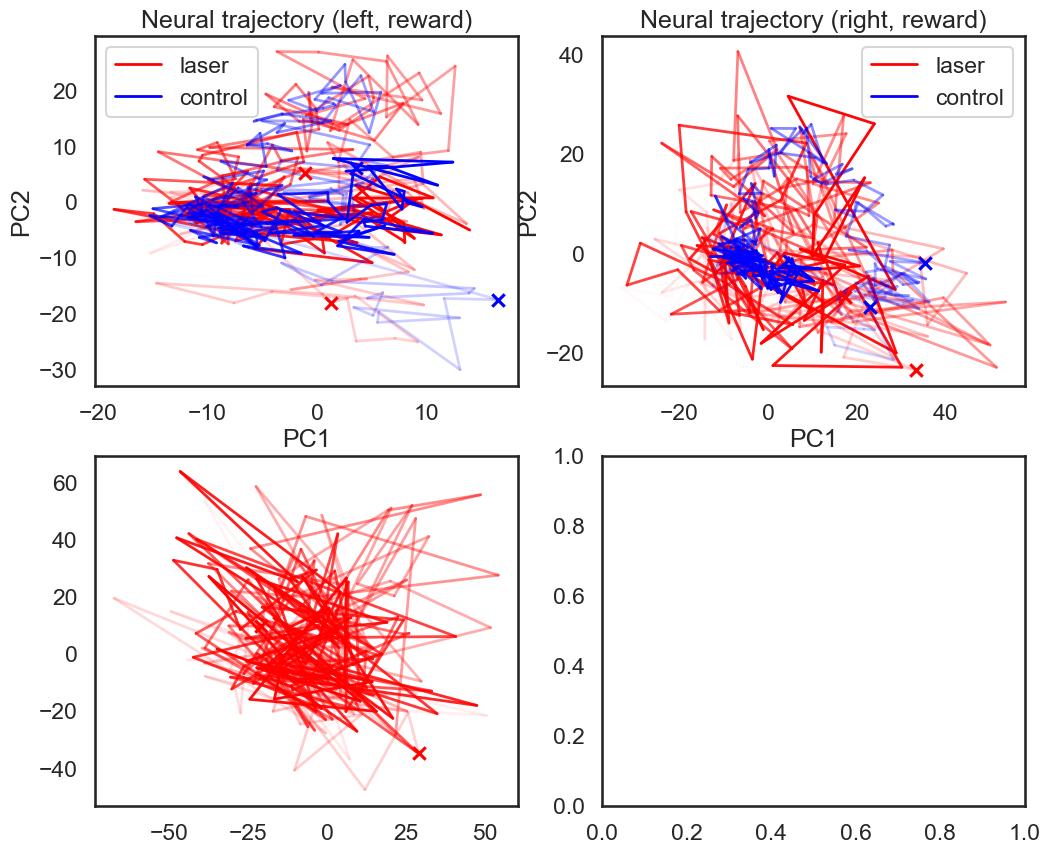

In [ ]:
from sklearn.decomposition import PCA

# ─── Generate PCA ───────────────────────────────────────
control_data = ndap.combine_rates(aligned, key=['control'])
control_data = np.nanmean(control_data, axis=1).T
pca_control = PCA(n_components=3).fit(control_data)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
key_time = [0, 1]

# ─── Top‐Left: Left Trials Trajectory ───────────────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['reward_left_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_left_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores, color='red', ax=axs[0,0], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['reward_left_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_left_control']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores,  color='blue',  ax=axs[0,0], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[0,0].legend()
axs[0,0].set_xlabel('PC1')
axs[0,0].set_ylabel('PC2')
axs[0,0].set_title('Neural trajectory (left, reward)')

# ─── Top‐Right: Right Trials Trajectory ────────────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['reward_right_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_right_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores, color='red',   ax=axs[0,1], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['reward_right_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_right_control']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores,  color='blue',  ax=axs[0,1], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[0,1].legend()
axs[0,1].set_xlabel('PC1')
axs[0,1].set_ylabel('PC2')
axs[0,1].set_title('Neural trajectory (right, reward)')

# ─── Bottom‐Left: left no reward trajectory ─────────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['nonreward_left_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_left_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores, color='red',   ax=axs[1,0], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['nonreward_left_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_left_control']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores,  color='blue',  ax=axs[1,0], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[1,0].legend()
axs[1,0].set_xlabel('PC1')
axs[1,0].set_ylabel('PC2')
axs[1,0].set_title('Neural trajectory (left, nonreward)')

# ─── Bottom‐Right: right no reward trajectory ───────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['nonreward_right_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_right_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores, color='red',   ax=axs[1,1], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['nonreward_right_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_right_control']['rate'], axis=1).T
scores = pca_control.transform(data)
ndap.plot_pca(scores,  color='blue',  ax=axs[1,1], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[1,1].legend()
axs[1,1].set_xlabel('PC1')
axs[1,1].set_ylabel('PC2')
axs[1,1].set_title('Neural trajectory (right, nonreward)')

plt.tight_layout()
plt.show()


## 4. Decoder analysis

### 4.1. Left and right axis

In [ ]:
# Run to get decoder
window_size = 100   # in ms

# Convert to numpy
left_rates_control = ndap.convert_dask_to_numpy(left_rates_control)
right_rates_control = ndap.convert_dask_to_numpy(right_rates_control)
left_rates_laser = ndap.convert_dask_to_numpy(left_rates_laser)
right_rates_laser = ndap.convert_dask_to_numpy(right_rates_laser)

# Get decoders
decoders, accs = ndap.get_decoders(left_rates_control, right_rates_control, 
                                window_size_ms=window_size, bin_size_ms=bin_size, max_iter=10000)

Selected decoder accuracy: 0.7142857142857143


Text(0, 0.5, 'Projection (--> right)')

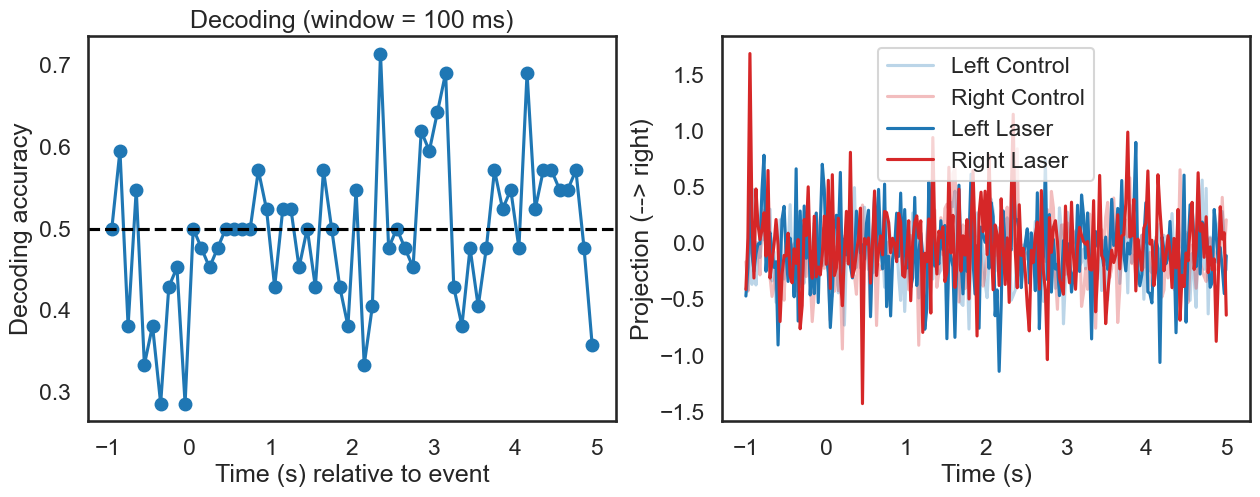

In [ ]:
# Select decoder
# Note: -7 to -6, shape looks very different
index = np.argmax(accs)
print('Selected decoder accuracy: ' + str(accs[index]))
decoder_left_right = decoders[index]


fig, axs = plt.subplots(1,2, figsize=(15,5))
# plot accuracy vs. time (bin centers)
# compute time‐bin centers
n_bins = aligned['reward_left_laser']['params']['n_timestep']
window_size_in_bins = max(1, int(round(window_size / bin_size)))
n_windows    = int(np.ceil(n_bins / window_size_in_bins))
time_bins    = np.linspace(time_range[0], time_range[1], n_bins, endpoint=False) + bin_size/1000/2
time_centers = [
    time_bins[i*window_size_in_bins : min((i+1)*window_size_in_bins, n_bins)].mean()
    for i in range(n_windows)
]
# plot
axs[0].plot(time_centers, accs, '-o')
axs[0].axhline(0.5, color='k', linestyle='--')
axs[0].set_xlabel('Time (s) relative to event')
axs[0].set_ylabel('Decoding accuracy')
axs[0].set_title(f'Decoding (window = {window_size} ms)')

# Plot projection
xaxis = np.linspace(time_range[0], time_range[1], n_bins)

left_control_trial_avg = np.nanmean(left_rates_control,axis=1)
right_control_trial_avg = np.nanmean(right_rates_control,axis=1)
proj_left_control = ndap.project(left_control_trial_avg, decoder_left_right)
proj_right_control = ndap.project(right_control_trial_avg, decoder_left_right)

left_laser_trial_avg = np.nanmean(left_rates_laser,axis=1)
right_laser_trial_avg = np.nanmean(right_rates_laser,axis=1)
proj_left_laser = ndap.project(left_laser_trial_avg, decoder_left_right)
proj_right_laser = ndap.project(right_laser_trial_avg, decoder_left_right)

axs[1].plot(xaxis, proj_left_control,  color=left_color,  alpha=alpha_ctrl,  label='Left Control')
axs[1].plot(xaxis, proj_right_control, color=right_color, alpha=alpha_ctrl,  label='Right Control')
axs[1].plot(xaxis, proj_left_laser,    color=left_color,  alpha=alpha_laser, label='Left Laser')
axs[1].plot(xaxis, proj_right_laser,   color=right_color, alpha=alpha_laser, label='Right Laser')

axs[1].legend()
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Projection (--> right)')

Text(0.5, 1.0, 'Spearman ρ = 0.271, p = 0.276')

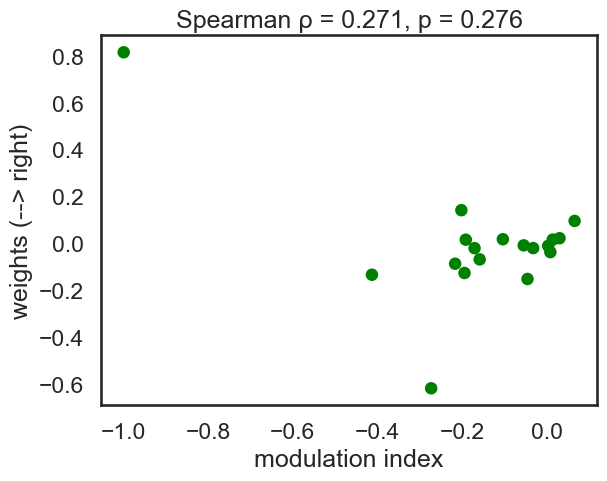

In [ ]:
# Correlation of the decoder weights and laser_mod_index
w_units = decoder_left_right.coef_[0]
if criteria is not None: 
    mod_index_included = laser_mod_index[criteria]
else: 
    mod_index_included = laser_mod_index

from scipy.stats import spearmanr
r_spear, p_spear = spearmanr(mod_index_included, w_units)

plt.scatter(mod_index_included, w_units, color='green', edgecolor='None')
plt.xlabel('modulation index')
plt.ylabel('weights (--> right)')
plt.title(f"Spearman ρ = {r_spear:.3f}, p = {p_spear:.3g}")

## 5. rSLDS

### 5.1 Prepare rSLDS data

Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']
Combining 2 conditions: ['nonreward_left_laser', 'reward_left_laser']
Combining 2 conditions: ['nonreward_right_laser', 'reward_right_laser']
[prepare_rslds_data] Data downsampled to 50 ms
[prepare_rslds_data] Data filled with 0 for nan
[prepare_rslds_data] Data z-scored
[prepare_rslds_data] Data downsampled to 50 ms
[prepare_rslds_data] Data filled with 0 for nan
[prepare_rslds_data] Data z-scored
[prepare_rslds_data] Data downsampled to 50 ms
[prepare_rslds_data] Data filled with 0 for nan
[prepare_rslds_data] Data z-scored


IndexError: index 67 is out of bounds for axis 0 with size 18

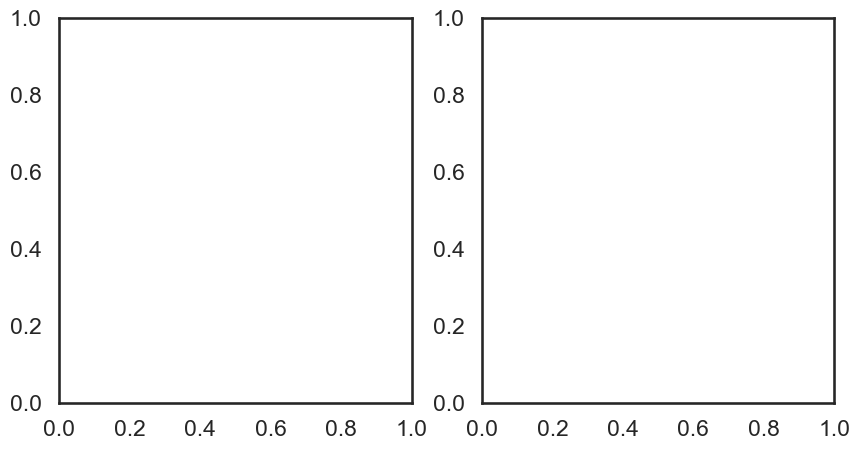

In [ ]:
# Define aligned data and time range
aligned = aligned_trial_start
criteria = None
target_bin_size_ms = 50
n_classes = 2

# Combine data
left_rates_control = ndap.combine_rates(aligned, key=['left','control'])
right_rates_control = ndap.combine_rates(aligned, key=['right','control'])
left_rates_laser = ndap.combine_rates(aligned, key=['left','laser'])
right_rates_laser = ndap.combine_rates(aligned, key=['right','laser'])

if criteria is not None:
    left_rates_control = left_rates_control[criteria, :, :]
    right_rates_control = right_rates_control[criteria, :, :]
    left_rates_laser = left_rates_laser[criteria, :, :]
    right_rates_laser = right_rates_laser[criteria, :, :]

# Prepare data for rSLDS
combined_data = np.concatenate([left_rates_control, right_rates_control], axis=1)
type1_label = np.array([[1, 0]] * left_rates_control.shape[1])
type2_label = np.array([[0, 1]] * right_rates_control.shape[1])
trial_types = np.r_[type1_label, type2_label]

rslds_data, inputs = ndap.prepare_rslds_data(combined_data, trial_types=trial_types, n_classes=n_classes,
                                             downsample=True, target_bin_size_ms=target_bin_size_ms, bin_size_ms=bin_size)
left_laser_data, left_laser_inputs = ndap.prepare_rslds_data(left_rates_laser, trial_types=type1_label, n_classes=n_classes,
                                             downsample=True, target_bin_size_ms=target_bin_size_ms, bin_size_ms=bin_size)
right_laser_data, right_laser_inputs = ndap.prepare_rslds_data(right_rates_laser, trial_types=type2_label, n_classes=n_classes,
                                             downsample=True, target_bin_size_ms=target_bin_size_ms, bin_size_ms=bin_size)                                                                                         

# Plot the data
unit_id = 67
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ndap.plot_sem(left_rates_control[unit_id], ax=axes[0])
ndap.plot_sem(right_rates_control[unit_id], ax=axes[1])
plt.show()

### 5.2. Fit a rSLDS model

In [ ]:
# Set rSLDS parameters
n_states = 4         # Number of discrete states (change as appropriate)
n_latent_dims = 2    # Number of latent dimensions (for visualization)
num_iters = 50      # Number of EM iterations

# Fit the rSLDS model
rslds, posterior, elbos = ndap.fit_rslds_model((rslds_data, inputs), n_states=n_states, n_latent_dims=n_latent_dims, num_iters=num_iters, emissions='gaussian')

Initializing model...


In [ ]:
# Save model
save_path = ndap.save_rslds_model(rslds, posterior, (rslds_data, inputs), 
                                file_name="cue_-1to2.joblib", folder_name=session_id,
                                elbos=elbos, time_range=time_range, bin_size=target_bin_size_ms)
print(f"Save rSLDS model to: {save_path}")

Save rSLDS model to: Results/rslds_models/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001//cue_-1to2.joblib


### 5.3. Plot model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyNeuroDAP as ndap

In [ ]:
# Load model
# if 'save_path' not in locals():
#     save_path = "Results/rslds_models/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/cue_-1to2.joblib"

save_path = "Results/rslds_models/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/choice_-1to2.joblib"
B = ndap.load_rslds_model(save_path)
print(f"Load rSLDS model from: {save_path}")

model = B["objects"]["model"]
posterior = B["objects"]["posterior"]
Y = B["data"]["Y_list"]
U = B["data"]["U_list"]
x = B["posterior"]["x_list"][0]
z = B["posterior"]["z_list"][0]
elbos = B["posterior"]["elbos"]
time_range = B["data"]["time_range"]
bin_size = B["data"]["bin_size"]

# Build type1_tuple and type2_tuple from Y and U
type1_tuple, type2_tuple = ndap.separate_rslds_tuple(Y, U)

Load rSLDS model from: Results/rslds_models/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/choice_-1to2.joblib


In [ ]:
# Optional: save additional stuff
# save_path = ndap.save_rslds_model(model, posterior, (Y, U), 
#                                 file_name="cue_-1to2.joblib", folder_name="Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001",
#                                 elbos=elbos, time_range=time_range, bin_size=50)

Key time (in sec): [-1.0, 0, 0.5]
time_range: (-1.0, 2.0) sec, bin_size: 50 ms


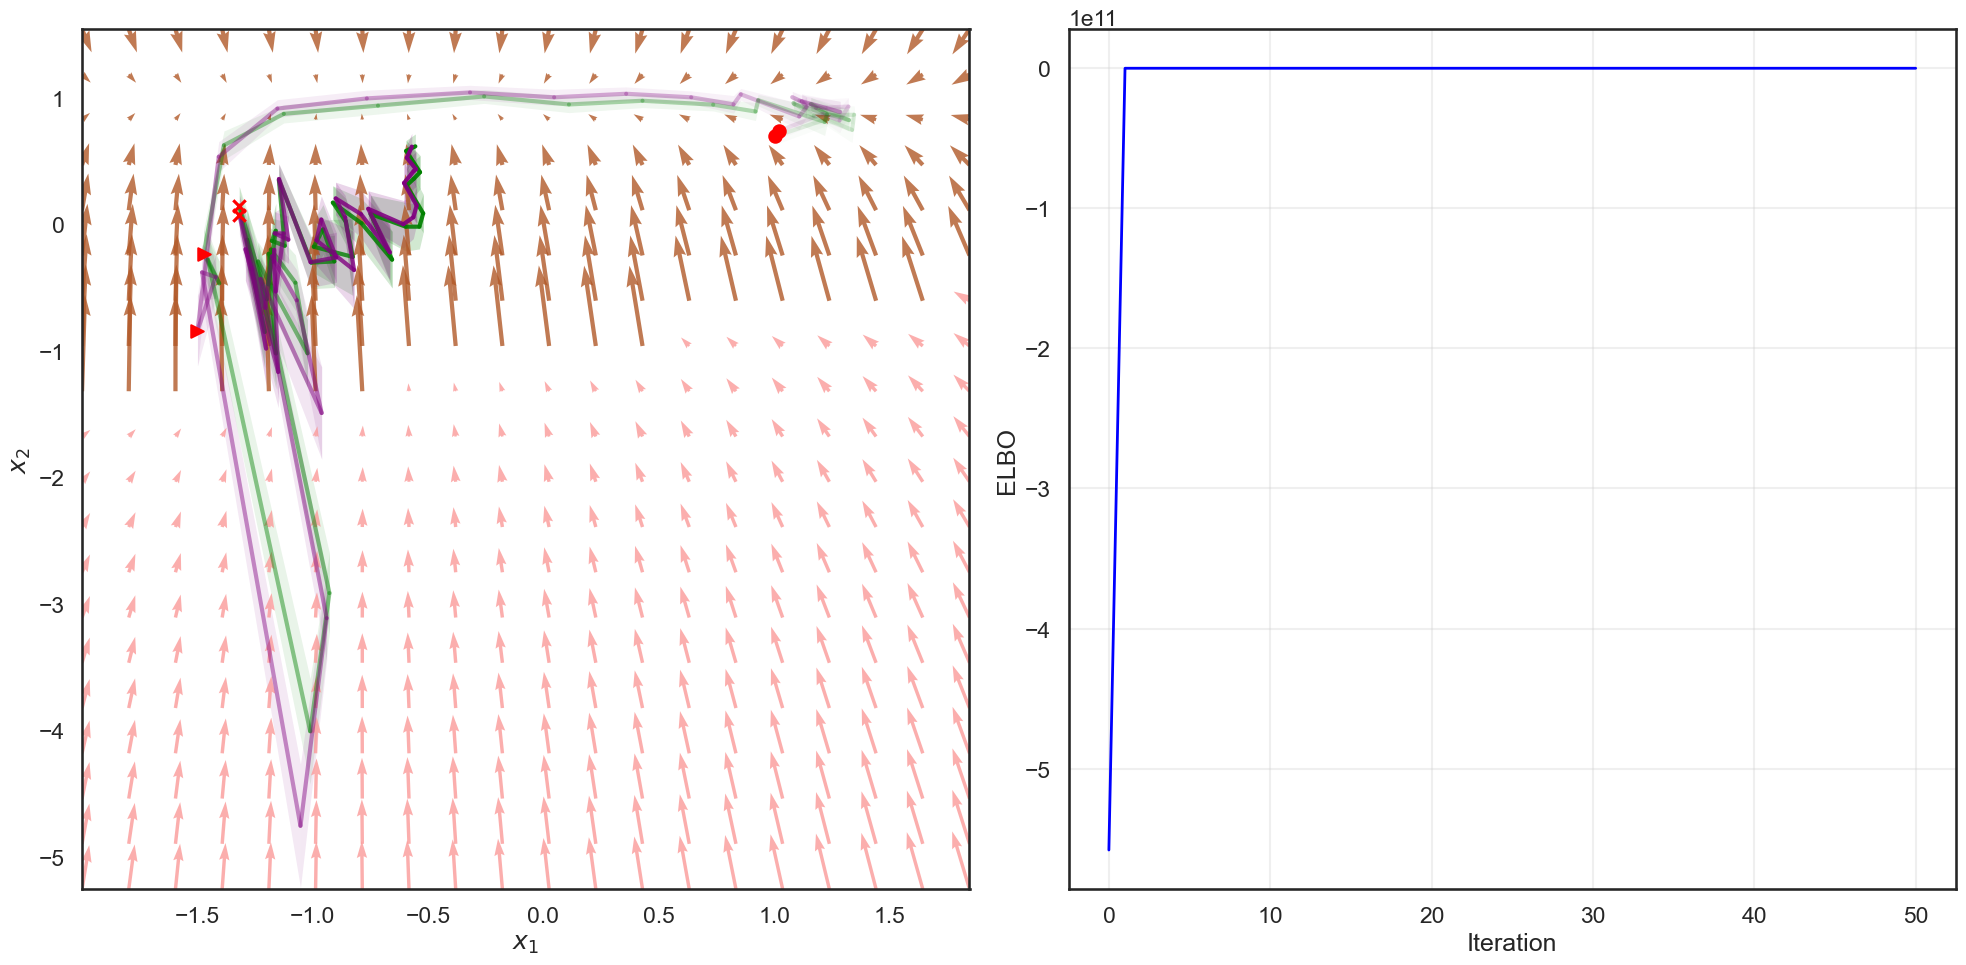

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
key_time = [time_range[0], 0, 0.5]
print(f"Key time (in sec): {key_time}")
print(f"time_range: {time_range} sec, bin_size: {bin_size} ms")

# Select trial indices
t1_idx = None
t2_idx = None

# Vector field / most-likely dynamics
ndap.plot_rslds_trajectory(model, posterior, type1_tuple, ax=axes[0], trial_idx=t1_idx,
                           color="green", key_time=key_time, time_range=time_range, bin_size=bin_size)
# ndap.plot_rslds_trajectory(model, posterior, (left_laser_data, left_laser_inputs), ax=axes[0], trial_idx=t1_idx,
#                            color="blue", key_time=key_time, time_range=time_range, bin_size=bin_size)
ndap.plot_rslds_trajectory(model, posterior, type2_tuple, ax=axes[0], trial_idx=t2_idx,
                           color="purple", key_time=key_time, time_range=time_range, bin_size=bin_size)
# ndap.plot_rslds_trajectory(model, posterior, (right_laser_data, right_laser_inputs), ax=axes[0], trial_idx=t2_idx,
#                            color="orange", key_time=key_time, time_range=time_range, bin_size=bin_size)
ndap.plot_rslds_dynamics(model, ax=axes[0])

# ELBO curve saved in the bundle
ndap.plot_rslds_elbo(elbos, ax=axes[1])

plt.tight_layout()
plt.show()

## Close file

In [ ]:
for f in _open_h5.values():
    try:
        f.close()
    except:
        pass

NameError: name '_open_h5' is not defined